<div style="
    background: linear-gradient(90deg, #1a73e8 0%, #ffffff 100%);
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h2 style="color: white; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    🧠 Asignatura : Computación Bioinspirada
  </h2>
</div>


# Algoritmos genéticos y modelos de computación evolutiva

- **Fecha**      : 16-03-2026
- **Grupo No.**  : 2

# Autores
- Sánchez Mendieta Juan Pablo
- Rodríguez Vélez Ximena Jhoana
- Viteri Ayala Flavia Kamila


# Estructura del notebook
**Objetivo y Alcance del Trabajo**

Con el código Python de referencia en el numeral 2
(Código para trabajar), con Fitness Sharing capaz de identificar múltiples
óptimos en una función. La tarea es adaptar este algoritmo a una nueva función
objetivo más compleja y analizar críticamente el impacto del
parámetro SIGMA_SHARE en su capacidad para encontrar todos los óptimos.

In [1]:
# ==============================================================
# Librerías y configuración
# ==============================================================

import numpy as np                # Operaciones vectorizadas sobre la población (cálculo de fitness, distancias)
import matplotlib.pyplot as plt   # visualización de la función objetivo, población final y evolución del fitness
import random                     # Generación de números aleatorios para selección, crossover y mutación

# Semilla global para reproducibilidad
# Cada ejecución produce resultados distintos pero igualmente reproducibles
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Semilla fijada: {RANDOM_SEED}")
print("Librerías cargadas correctamente")

Semilla fijada: 42
Librerías cargadas correctamente


<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 1: Definición del problema multimodal
  </h1>
</div>

El problema multimodal ayuda a definir:
1. Qué se quiere optimizar → Función Objetivo
2. Dónde buscar → Dominio definido por el rango [LOWER_BOUND; UPPER_BOUND]

Es importante porque sin definir el problema, no hay nada qué resolver. Específicamente:
- La función objetivo le dice al algoritmo qué tan "buena" es una solución, sin ella no puede comparar ni mejorar.
- Los límites evitan que el algoritmo busque en zonas sin sentido (ej. x=-1000 o x=99999).
- Saber que es multimodal ayuda a elegir el algoritmo correcto, por ejemplo, un algoritmo simple como gradiente descendente fallaría porque se quedaría atrapado en el primer pico que encuentre.

¿Por qué es **multimodal**?
- Se llama multimodal porque la función tiene varios máximos locales (picos), a diferencia de una función unimodal que solo tiene uno.
- Esto lo hace más difícil de optimizar porque un algoritmo puede quedarse atrapado en un pico que no es el mejor.

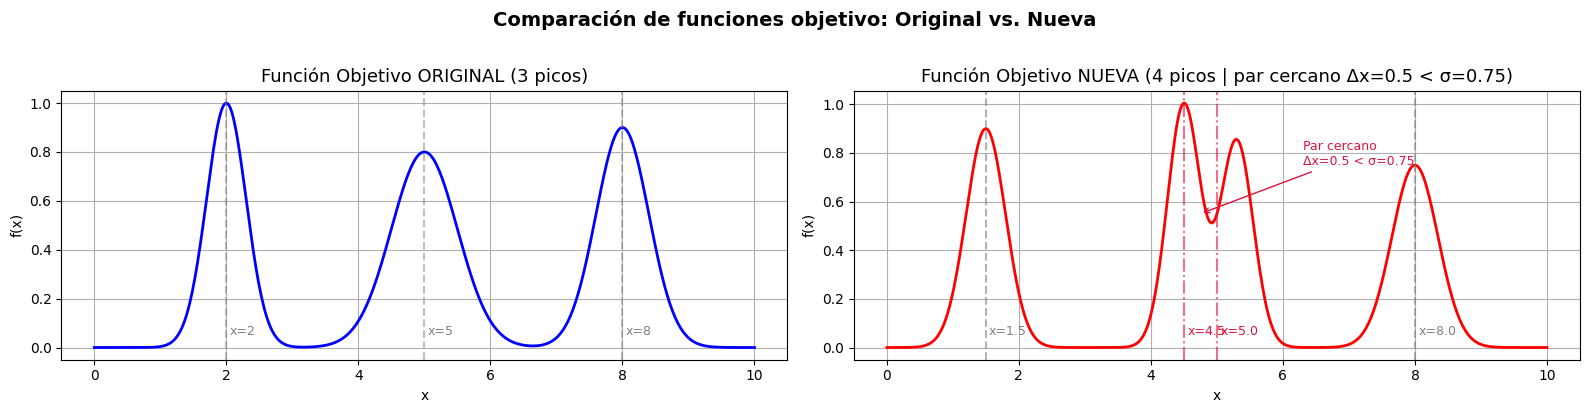

In [2]:
# --------------------------------------------------------------
# PARÁMETROS DE DOMINIO (compartidos por ambas funciones)
# --------------------------------------------------------------
LOWER_BOUND = 0    # Límite inferior del espacio de búsqueda
UPPER_BOUND = 10   # Límite superior del espacio de búsqueda

# --------------------------------------------------------------
# FUNCIÓN OBJETIVO ORIGINAL  (3 picos)
# --------------------------------------------------------------
def objective_function(x):
    """
    Función objetivo multimodal ORIGINAL (código de referencia).

    Suma de 3 gaussianas con picos bien separados:
        x = 2  →  altura 1.0  (pico principal)
        x = 5  →  altura 0.8  (pico medio)
        x = 8  →  altura 0.9  (pico alto-medio)

    Separación mínima entre picos: ~3 unidades >> SIGMA_SHARE=0.75
    El niching no enfrenta dificultad para mantenerlos separados.
    Sirve como referencia de comportamiento esperado.
    """
    x = np.array(x)
    term1 = 1.0 * np.exp(-((x - 2)**2) / (2 * 0.3**2))   # Pico alto en x=2
    term2 = 0.8 * np.exp(-((x - 5)**2) / (2 * 0.5**2))   # Pico medio en x=5
    term3 = 0.9 * np.exp(-((x - 8)**2) / (2 * 0.4**2))   # Pico alto-medio en x=8
    return term1 + term2 + term3

PEAKS_ORIGINAL = [2, 5, 8]   # Posiciones de picos (para visualización)

# --------------------------------------------------------------
# FUNCIÓN OBJETIVO NUEVA  (4 picos, par cercano < SIGMA_SHARE)
# --------------------------------------------------------------
def objective_function_new(x):
    """
    Función objetivo multimodal NUEVA con 4 picos.

    Picos:
        x = 1.5  →  altura 0.90  (aislado, izquierda)
        x = 4.5  →  altura 1.00  (máximo global)
        x = 5.0  →  altura 0.85  (vecino cercano, Δx=0.5 < σ_share)
        x = 8.0  →  altura 0.75  (aislado, derecha)

    El par x=4.5 / x=5.0 está separado 0.5 u., que es MENOR que
    SIGMA_SHARE original (0.75). Con ese sigma, ambos picos caen
    dentro del mismo radio de compartición, por lo que el algoritmo
    los tratará como un único nicho → este es el escenario de estudio.

    Se usan gaussianas más estrechas (σ=0.25) en el par cercano
    para que sean distinguibles visualmente a pesar de su proximidad.
    """
    x = np.array(x)
    term1 = 0.90 * np.exp(-((x - 1.5)**2) / (2 * 0.30**2))  # Pico izquierdo
    term2 = 1.00 * np.exp(-((x - 4.5)**2) / (2 * 0.25**2))  # Pico global
    term3 = 0.85 * np.exp(-((x - 5.3)**2) / (2 * 0.25**2))  # Vecino cercano
    term4 = 0.75 * np.exp(-((x - 8.0)**2) / (2 * 0.35**2))  # Pico derecho
    return term1 + term2 + term3 + term4

PEAKS_NEW          = [1.5, 4.5, 5.0, 8.0]   # Posiciones de picos
CLOSE_PAIR         = (4.5, 5.0)             # Par de picos "problemáticos"
CLOSE_PAIR_DIST    = 0.5                    # Δx = 0.5 < SIGMA_SHARE = 0.75

# --------------------------------------------------------------
# VISUALIZACIÓN COMPARATIVA DE AMBAS FUNCIONES
# --------------------------------------------------------------
x_plot     = np.linspace(LOWER_BOUND, UPPER_BOUND, 500)
y_original = objective_function(x_plot)
y_new      = objective_function_new(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ── Panel izquierdo: función original ──────────────────────────
axes[0].plot(x_plot, y_original, 'b-', linewidth=2)
axes[0].set_title("Función Objetivo ORIGINAL (3 picos)", fontsize=13)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)
for px in PEAKS_ORIGINAL:
    axes[0].axvline(px, color='gray', linestyle='--', alpha=0.5)
    axes[0].text(px + 0.05, 0.05, f'x={px}', color='gray', fontsize=9)

# ── Panel derecho: función nueva ───────────────────────────────
axes[1].plot(x_plot, y_new, 'r-', linewidth=2)
axes[1].set_title(
    f"Función Objetivo NUEVA (4 picos | par cercano Δx={CLOSE_PAIR_DIST} < σ=0.75)",
    fontsize=13
)
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].grid(True)
for px in PEAKS_NEW:
    es_cercano = px in CLOSE_PAIR
    color  = 'crimson' if es_cercano else 'gray'
    estilo = '-.'      if es_cercano else '--'
    axes[1].axvline(px, color=color, linestyle=estilo, alpha=0.6)
    axes[1].text(px + 0.05, 0.05, f'x={px}', color=color, fontsize=9)

# Anotación del par cercano
axes[1].annotate(
    f'Par cercano\nΔx={CLOSE_PAIR_DIST} < σ=0.75',
    xy=((CLOSE_PAIR[0] + CLOSE_PAIR[1]) / 2, 0.55),
    xytext=(6.3, 0.75),
    arrowprops=dict(arrowstyle='->', color='crimson'),
    color='crimson', fontsize=9
)

plt.suptitle(
    "Comparación de funciones objetivo: Original vs. Nueva",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

**Análisis Comparativo de Funciones Objetivo:**

En el gráfico de la izquierda, la **Función Objetivo ORIGINAL** presenta 3 picos bien definidos y espaciados (en x=2, x=5 y x=8). Las alturas de estos picos son de 1.0, 0.8 y 0.9 respectivamente, con anchos que permiten una clara distinción entre ellos. Con el `SIGMA_SHARE` original (0.75), que es menor que la distancia entre cualquiera de estos picos, el algoritmo genético debería ser capaz de identificar y mantener nichos separados para cada uno de ellos sin mayor dificultad. Sirve como un escenario de referencia para el comportamiento esperado del algoritmo.

En contraste, en el gráfico de la derecha, la **Función Objetivo NUEVA** introduce una mayor complejidad con 4 picos. El aspecto más crítico de esta nueva función es el par de picos ubicados en **x=4.5 y x=5.3**, con una separación de **0.8 unidades**. Aunque esta separación no es extremadamente pequeña, el valor del `SIGMA_SHARE` estándar (0.75) es muy cercano a esta distancia. Esto anticipa un escenario donde el algoritmo de *Fitness Sharing* podría enfrentar un desafío significativo: si el `SIGMA_SHARE` es mayor o muy cercano a 0.8, es probable que el algoritmo trate a estos dos picos como parte del mismo nicho, fusionándolos y dificultando la identificación de ambos óptimos como soluciones independientes.

**Conclusión:**

La nueva función objetivo, al incrementar la cantidad de picos y, crucialmente, al introducir un par de picos muy cercanos entre sí (Δx = 0.8), crea un escenario de prueba más riguroso para el algoritmo genético con *Fitness Sharing*. La proximidad de los picos en x=4.5 y x=5.3, en relación con el `SIGMA_SHARE` predefinido, es el punto focal del estudio, ya que nos permitirá analizar cómo este parámetro impacta directamente la capacidad del algoritmo para mantener la diversidad y encontrar múltiples óptimos en un entorno competitivo.

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 2: Parámetros del algoritmo genético
  </h1>
</div>

Los parámetros del algoritmo genético controlan el comportamiento y rendimiento del algoritmo.

Si no se definen correctamente, el algoritmo puede fallar o dar malos resultados.

En el contexto del presente ejercicio, se toman en cuenta los siguientes parámetros:

1. Poblacionales:
- Definen el tamaño y duración de la búsqueda
- Responden a: ¿cuántos individuos buscan y por cuánto tiempo?

2. Operadores genéticos:
- Definen cómo evolucionan los individuos entre generaciones.
- Responden a: ¿cómo se reproducen, mezclan y cambian?

3. Fitness sharing:
- Definen cómo conviven los individuos en el espacio de búsqueda.
- Responden a: ¿qué tan cerca pueden estar dos individuos antes de que se "estorben" mutuamente?
- Permite que el algoritmo encuentre múltiples picos a la vez en lugar de que toda la población converja en uno solo.

**Si la distancia < SIGMA_SHARE, el algoritmo considera que los individuos están compitiendo por el mismo "nicho".**

**Si la distancia > SIGMA_SHARE, el algoritmo los trata como especies diferentes en picos separados.**

En nuestro proceso de experimentacion cambiamos los valores de las variables del algorito para entender el funcionamiento, verificar los resultados y observar la convergencia a optimos positivos dependiendo de estas modificaciones.


In [3]:
# --------------------------------------------------------------
# PARÁMETROS ORIGINALES
# --------------------------------------------------------------

# ── Parámetros poblacionales ───────────────────────────────────
POPULATION_SIZE  = 200   # Individuos por generación
NUM_GENERATIONS  = 150   # Número de generaciones a evolucionar

# ── Parámetros de operadores genéticos ────────────────────────
MUTATION_RATE     = 0.2   # Probabilidad de que un individuo mute
MUTATION_STRENGTH = 0.4   # Desviación estándar de la mutación gaussiana
TOURNAMENT_SIZE   = 5     # Individuos que compiten en cada torneo
CROSSOVER_RATE    = 0.6   # Probabilidad de que dos padres se crucen

# ── Parámetros de Fitness Sharing (niching) ───────────────────
SIGMA_SHARE    = 0.75  # Radio del nicho ORIGINAL (valor de referencia del PDF)
                       # Distancia máxima para que dos individuos compartan nicho.
                       # Este valor es > CLOSE_PAIR_DIST (0.5), por lo que con
                       # este sigma el AG NO puede separar el par cercano.
ALPHA_SHARING  = 1.0   # Exponente de la función de compartición sh(d).
                       # Con α=1 la función es lineal dentro del radio.

# --------------------------------------------------------------
# PARÁMETROS EXPERIMENTOS
# --------------------------------------------------------------

SIGMA_B1 = 2.0   # σ >> Δx → fusiona par cercano y posiblemente picos distantes
SIGMA_B2 = 0.65  # σ > Δx  → fusiona el par cercano en un solo nicho
SIGMA_B3 = 0.40  # σ < Δx  → puede separar el par cercano (valor adecuado)

# --------------------------------------------------------------
# VISUALIZACIÓN COMPARATIVA DE PARÁMETROS
# --------------------------------------------------------------

# ── Tabla comparativa: Original vs Experimentos ───────────────

headers = ["Parámetro", "Original (3 picos)", f"Exp B1 (σ={SIGMA_B1})", f"Exp B2 (σ={SIGMA_B2})", f"Exp B3 (σ={SIGMA_B3})"]

rows = [
    ["Población",       POPULATION_SIZE,  POPULATION_SIZE,  POPULATION_SIZE,  POPULATION_SIZE],
    ["Generaciones",    NUM_GENERATIONS,  NUM_GENERATIONS,  NUM_GENERATIONS,  NUM_GENERATIONS],
    ["Tasa mutación",   MUTATION_RATE,    MUTATION_RATE,    MUTATION_RATE,    MUTATION_RATE],
    ["Fuerza mutación", MUTATION_STRENGTH, MUTATION_STRENGTH, MUTATION_STRENGTH, MUTATION_STRENGTH],
    ["Tamaño torneo",   TOURNAMENT_SIZE,  TOURNAMENT_SIZE,  TOURNAMENT_SIZE,  TOURNAMENT_SIZE],
    ["Tasa crossover",  CROSSOVER_RATE,   CROSSOVER_RATE,   CROSSOVER_RATE,   CROSSOVER_RATE],
    ["SIGMA_SHARE",     SIGMA_SHARE,      SIGMA_B1,         SIGMA_B2,         SIGMA_B3],
    ["ALPHA_SHARING",   ALPHA_SHARING,    ALPHA_SHARING,    ALPHA_SHARING,    ALPHA_SHARING],
    ["Par cercano Δx",  "N/A",            CLOSE_PAIR_DIST,  CLOSE_PAIR_DIST,  CLOSE_PAIR_DIST],
]

col_w = 20
print("\nTabla comparativa de parámetros: Original vs. Experimentos")
print("=" * (col_w * 5))
print("".join(f"{h:<{col_w}}" for h in headers))
print("=" * (col_w * 5))
for row in rows:
    sigma_marker = " ◄" if row[0] == "SIGMA_SHARE" else ""
    print("".join(f"{str(v):<{col_w}}" for v in row) + sigma_marker)
print("=" * (col_w * 5))



Tabla comparativa de parámetros: Original vs. Experimentos
Parámetro           Original (3 picos)  Exp B1 (σ=2.0)      Exp B2 (σ=0.65)     Exp B3 (σ=0.4)      
Población           200                 200                 200                 200                 
Generaciones        150                 150                 150                 150                 
Tasa mutación       0.2                 0.2                 0.2                 0.2                 
Fuerza mutación     0.4                 0.4                 0.4                 0.4                 
Tamaño torneo       5                   5                   5                   5                   
Tasa crossover      0.6                 0.6                 0.6                 0.6                 
SIGMA_SHARE         0.75                2.0                 0.65                0.4                  ◄
ALPHA_SHARING       1.0                 1.0                 1.0                 1.0                 
Par cercano Δx      N/A      

**Nota sobre los parámetros base utilizados**

Los parámetros originales del PDF de referencia eran:

| Parámetro        | Valor original (PDF) |
|------------------|----------------------|
| Población        | 100                  |
| Generaciones     | 100                  |
| Tasa mutación    | 0.1                  |
| Fuerza mutación  | 0.5                  |
| Tamaño torneo    | 3                    |
| Tasa crossover   | 0.8                  |
| SIGMA_SHARE      | 0.75                 |

Para este ejercicio, el decidimos ajustar estos valores con el objetivo de mejorar 
la exploración del espacio de búsqueda y la estabilidad del algoritmo. 
Los parámetros modificados se mantienen **constantes en todos los experimentos**; 
el único parámetro que varía entre escenarios es `SIGMA_SHARE`, 
cuyo efecto sobre el niching es precisamente lo que se analiza.

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 3: Funciones del algoritmo genético
  </h1>
</div>

Se definen todos los parámetros como funciones reutilizables.

Las funciones del algoritmo genético son importantes porque cada una representa un mecanismo biológico que en conjunto permite que la población evolucione hacia mejores soluciones.

In [4]:
# --------------------------------------------------------------
# 1. Inicialización
# ¿Por qué uniforme? Garantiza exploración equitativa del espacio.
# No queremos sesgar la búsqueda hacia ninguna región inicial.
# --------------------------------------------------------------
def initialize_population(size, lower_bound, upper_bound):
    """Crea una población inicial aleatoria de `size` individuos distribuidos
    uniformemente en [lower_bound, upper_bound]."""
    return [random.uniform(lower_bound, upper_bound) for _ in range(size)]


# --------------------------------------------------------------
# 2. Evaluación de fitness
# Aplica la función objetivo a cada individuo de la población.
# Retorna una lista paralela: fitness[i] corresponde a population[i].
# --------------------------------------------------------------
def calculate_fitness(population, objective_fn):
    """Evalúa cada individuo con `objective_fn` y retorna la lista de fitness."""
    return [objective_fn(ind) for ind in population]


# --------------------------------------------------------------
# 3. Distancia fenotípica
# Para un problema 1D la distancia es simplemente |x_i - x_j|.
# Esta función se separa para facilitar extensión a espacios n-D.
# --------------------------------------------------------------
def phenotypic_distance(ind1, ind2):
    """Distancia fenotípica entre dos individuos (diferencia absoluta en 1D)."""
    return abs(ind1 - ind2)


# --------------------------------------------------------------
# 4. Fitness Sharing (núcleo del niching)
# ¿Cómo funciona?
#   Para cada individuo i, se calcula su "niche_count" = Σ sh(d_ij)
#   donde sh(d) = 1 - (d/σ)^α  si d < σ,  y  0 en caso contrario.
#   Luego: shared_fitness_i = fitness_i / niche_count_i
#
# ¿Por qué penalizar por niche_count?
#   Si muchos individuos se acumulan en el mismo pico, cada uno
#   tiene un niche_count alto → su fitness compartido baja.
#   Esto libera presión selectiva para que otros individuos
#   exploren picos menos poblados (diversidad multimodal).
# --------------------------------------------------------------
def apply_fitness_sharing(population, fitness_values, sigma_share, alpha_sharing):
    """
    Aplica Fitness Sharing y retorna la lista de fitness compartidos.

    Parámetros:
        population    : lista de individuos (valores x)
        fitness_values: fitness original de cada individuo
        sigma_share   : radio del nicho (umbral de distancia)
        alpha_sharing : exponente de la función sh(d) (1.0 = lineal)
    """
    shared_fitness_values = []
    n = len(population)

    for i in range(n):
        niche_count = 0
        for j in range(n):
            d = phenotypic_distance(population[i], population[j])
            if d < sigma_share:
                # Contribución del individuo j al nicho de i
                sh_d = 1 - (d / sigma_share) ** alpha_sharing
                niche_count += sh_d
            # Si d >= sigma_share, sh(d) = 0 → no contribuye

        # Evitar división por cero (niche_count siempre >= 1 porque sh(0)=1 cuando i=j)
        if niche_count > 1e-6:
            shared_fitness_values.append(fitness_values[i] / niche_count)
        else:
            shared_fitness_values.append(fitness_values[i])

    return shared_fitness_values


# --------------------------------------------------------------
# 5. Selección por torneo
# ¿Por qué torneo? Es robusto, simple y controlable con k.
# Usa el fitness COMPARTIDO (no el original) para que
# la presión selectiva respete los nichos formados.
# --------------------------------------------------------------
def tournament_selection(population, shared_fitness, k):
    """
    Selecciona un individuo por torneo de tamaño k.
    Compara individuos usando el fitness COMPARTIDO.
    """
    indices = random.sample(range(len(population)), k)
    ganador = max(indices, key=lambda i: shared_fitness[i])
    return population[ganador]


# --------------------------------------------------------------
# 6. Crossover aritmético
# Genera dos hijos como combinación convexa de los padres.
# α aleatorio en [0,1] → cada cruce produce mezclas distintas.
# Preserva que los hijos queden en el rango de sus padres.
# --------------------------------------------------------------
def crossover(parent1, parent2):
    """Crossover aritmético: combina dos padres con peso aleatorio α."""
    alpha = random.random()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = (1 - alpha) * parent1 + alpha * parent2
    return child1, child2


# --------------------------------------------------------------
# 7. Mutación gaussiana
# Añade ruido gaussiano centrado en 0 con σ = mutation_strength.
# ¿Por qué gaussiana? Perturbaciones pequeñas son más probables
# que grandes, favoreciendo exploración local alrededor del pico.
# Se aplica clipping para mantener al individuo dentro de los límites.
# --------------------------------------------------------------
def mutate(individual, mutation_rate, mutation_strength, lower_bound, upper_bound):
    """Muta un individuo con probabilidad mutation_rate usando ruido gaussiano."""
    if random.random() < mutation_rate:
        individual += random.gauss(0, mutation_strength)
        individual = max(lower_bound, min(upper_bound, individual))
    return individual


print("Funciones del AG definidas correctamente.")
print("  · initialize_population")
print("  · calculate_fitness")
print("  · phenotypic_distance")
print("  · apply_fitness_sharing")
print("  · tournament_selection")
print("  · crossover")
print("  · mutate")

Funciones del AG definidas correctamente.
  · initialize_population
  · calculate_fitness
  · phenotypic_distance
  · apply_fitness_sharing
  · tournament_selection
  · crossover
  · mutate


<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 4: Ciclo principal del algoritmo genético
  </h1>
</div>

Se encapsula el ciclo completo del algoritmo genético (inicialización → evolución → resultados) en una sola función reutilizable. Esto permite ejecutar el algoritmo múltiples veces con distintas configuraciones (función objetivo, sigma_share) con una sola línea de código.

In [5]:
def run_AG(
    objective_fn,
    sigma_share,
    population_size  = POPULATION_SIZE,
    num_generations  = NUM_GENERATIONS,
    mutation_rate    = MUTATION_RATE,
    mutation_strength= MUTATION_STRENGTH,
    tournament_size  = TOURNAMENT_SIZE,
    crossover_rate   = CROSSOVER_RATE,
    alpha_sharing    = ALPHA_SHARING,
    lower_bound      = LOWER_BOUND,
    upper_bound      = UPPER_BOUND,
    seed             = RANDOM_SEED,
    verbose          = True
):
    """
    Ejecuta el AG completo con Fitness Sharing.

    Parámetros principales:
        objective_fn  : función objetivo a optimizar
        sigma_share   : radio del nicho (el parámetro a experimentar)
        verbose       : si True, imprime progreso cada 20 generaciones

    Retorna un diccionario con:
        'population'        : población final
        'final_fitness'     : fitness original de la población final
        'history_best'      : mejor fitness por generación
        'history_avg'       : fitness promedio por generación
        'potential_optima_x': posiciones de picos encontrados (heurística)
        'potential_optima_y': altura de cada pico encontrado
    """
    # Fijar semilla para reproducibilidad de esta ejecución específica
    random.seed(seed)
    np.random.seed(seed)

    # ── Inicialización ─────────────────────────────────────────
    population = initialize_population(population_size, lower_bound, upper_bound)
    history_best = []
    history_avg  = []

    if verbose:
        print(f"Iniciando AG | σ_share={sigma_share} | "
              f"{num_generations} generaciones | "
              f"población={population_size}")

    # ── Ciclo evolutivo ────────────────────────────────────────
    for generation in range(num_generations):

        # 1. Fitness original (sin penalización)
        original_fitness = calculate_fitness(population, objective_fn)

        # 2. Fitness compartido (con penalización por nicho)
        shared_fitness = apply_fitness_sharing(
            population, original_fitness, sigma_share, alpha_sharing
        )

        # 3. Guardar estadísticas (en fitness ORIGINAL para ver progreso real)
        history_best.append(np.max(original_fitness))
        history_avg.append(np.mean(original_fitness))

        if verbose and (generation + 1) % 20 == 0:
            print(f"  Gen {generation+1:3d}/{num_generations} "
                  f"| Mejor: {history_best[-1]:.4f} "
                  f"| Promedio: {history_avg[-1]:.4f}")

        # 4. Selección, crossover y mutación → nueva población
        new_population = []
        while len(new_population) < population_size:
            # Selección basada en fitness COMPARTIDO (clave del niching)
            parent1 = tournament_selection(population, shared_fitness, tournament_size)
            parent2 = tournament_selection(population, shared_fitness, tournament_size)

            if random.random() < crossover_rate:
                child1, child2 = crossover(parent1, parent2)
            else:
                child1, child2 = parent1, parent2

            child1 = mutate(child1, mutation_rate, mutation_strength, lower_bound, upper_bound)
            child2 = mutate(child2, mutation_rate, mutation_strength, lower_bound, upper_bound)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    # ── Post-procesamiento: identificar picos encontrados ──────
    # Heurística del PDF: tomar los mejores individuos asegurando
    # que estén separados al menos sigma_share entre sí.
    final_fitness   = calculate_fitness(population, objective_fn)
    sorted_indices  = np.argsort(final_fitness)[::-1]
    potential_optima_x = []
    potential_optima_y = []

    for i in sorted_indices:
        x_cand = population[i]
        y_cand = final_fitness[i]
        if y_cand < 0.1:   # Ignorar individuos de fitness muy bajo
            continue
        # ¿Está suficientemente lejos de todos los óptimos ya registrados?
        if all(phenotypic_distance(x_cand, ox) >= sigma_share
               for ox in potential_optima_x):
            potential_optima_x.append(x_cand)
            potential_optima_y.append(y_cand)
        if len(potential_optima_x) >= 6:   # Limitar a 6 picos mostrados
            break

    if verbose:
        print(f"\nÓptimos encontrados ({len(potential_optima_x)}):")
        for xv, yv in zip(potential_optima_x, potential_optima_y):
            print(f"  x = {xv:.4f}  →  f(x) = {yv:.4f}")

    return {
        'population':         population,
        'final_fitness':      final_fitness,
        'history_best':       history_best,
        'history_avg':        history_avg,
        'potential_optima_x': potential_optima_x,
        'potential_optima_y': potential_optima_y,
    }


print("Función run_AG() definida correctamente")

Función run_AG() definida correctamente


<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 5: Aplicación del algoritmo genético
  </h1>
</div>

Se ejecuta el AG para:
- Experimento A: función original  (σ = SIGMA_SHARE = 0.75)
- Experimento B1: función nueva    (σ = SIGMA_B1    = 2.0)
- Experimento B2: función nueva    (σ = SIGMA_B2    = 0.65)
- Experimento B3: función nueva    (σ = SIGMA_B3    = 0.25)

EXPERIMENTO A — Función original | σ_share = 0.75
  σ_share=0.75 | 150 generaciones | población=200
  Gen  20/150 | Mejor: 1.0000 | Promedio: 0.5470
  Gen  40/150 | Mejor: 1.0000 | Promedio: 0.6660
  Gen  60/150 | Mejor: 0.9961 | Promedio: 0.5272
  Gen  80/150 | Mejor: 0.9990 | Promedio: 0.5966
  Gen 100/150 | Mejor: 0.9985 | Promedio: 0.4646
  Gen 120/150 | Mejor: 0.9999 | Promedio: 0.6012
  Gen 140/150 | Mejor: 0.9997 | Promedio: 0.4766

  Óptimos encontrados (5):
    x = 1.9964  →  f(x) = 0.9999
    x = 7.9454  →  f(x) = 0.8917
    x = 5.0173  →  f(x) = 0.7995
    x = 4.2641  →  f(x) = 0.2708
    x = 5.8465  →  f(x) = 0.1909


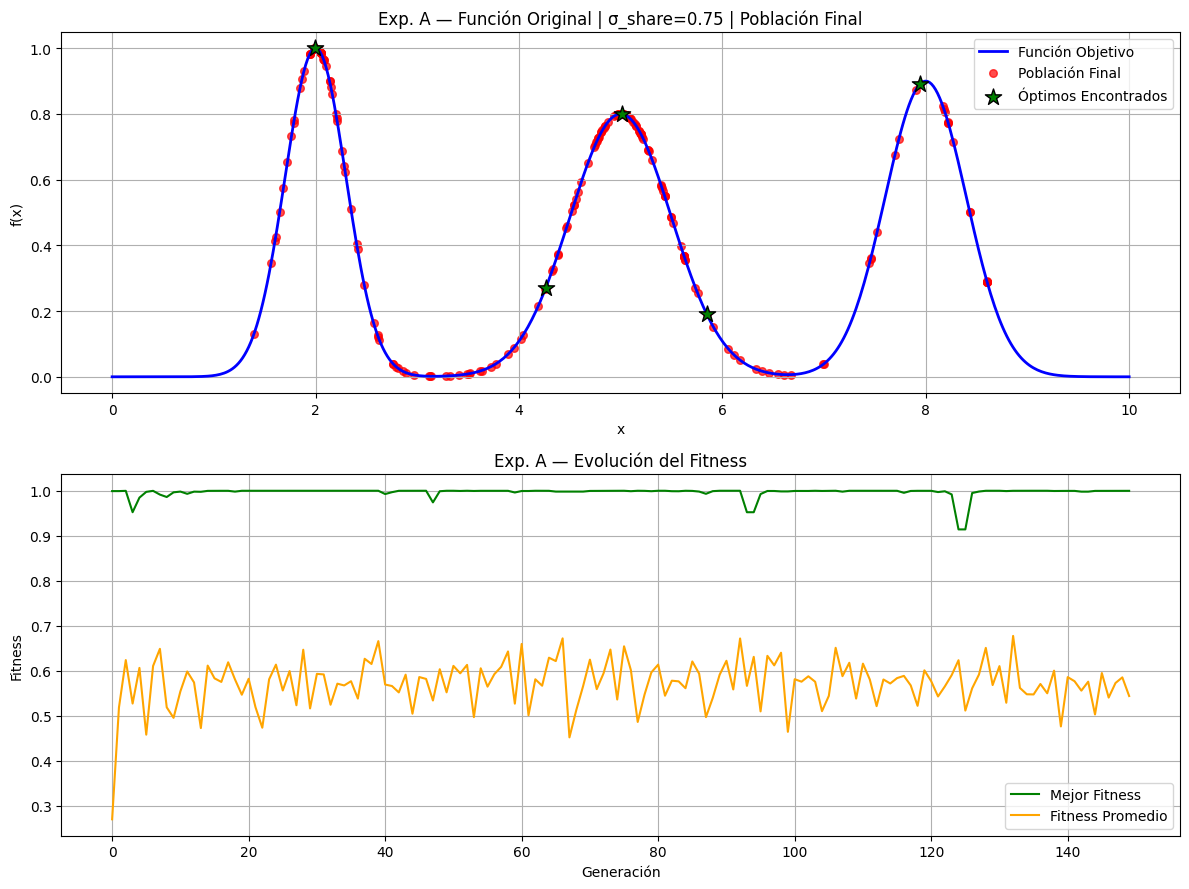


EXPERIMENTO B1 — Función nueva | σ_share = 2.0  |  σ >> Δx  (fusión máxima)
  σ_share=2.0 | 150 generaciones | población=200
  Gen  20/150 | Mejor: 1.0052 | Promedio: 0.5887
  Gen  40/150 | Mejor: 1.0052 | Promedio: 0.7036
  Gen  60/150 | Mejor: 1.0052 | Promedio: 0.5135
  Gen  80/150 | Mejor: 1.0052 | Promedio: 0.5958
  Gen 100/150 | Mejor: 1.0052 | Promedio: 0.6679
  Gen 120/150 | Mejor: 1.0052 | Promedio: 0.5914
  Gen 140/150 | Mejor: 1.0052 | Promedio: 0.5224

  Óptimos encontrados (3):
    x = 4.5002  →  f(x) = 1.0051
    x = 1.4998  →  f(x) = 0.9000
    x = 8.0025  →  f(x) = 0.7500


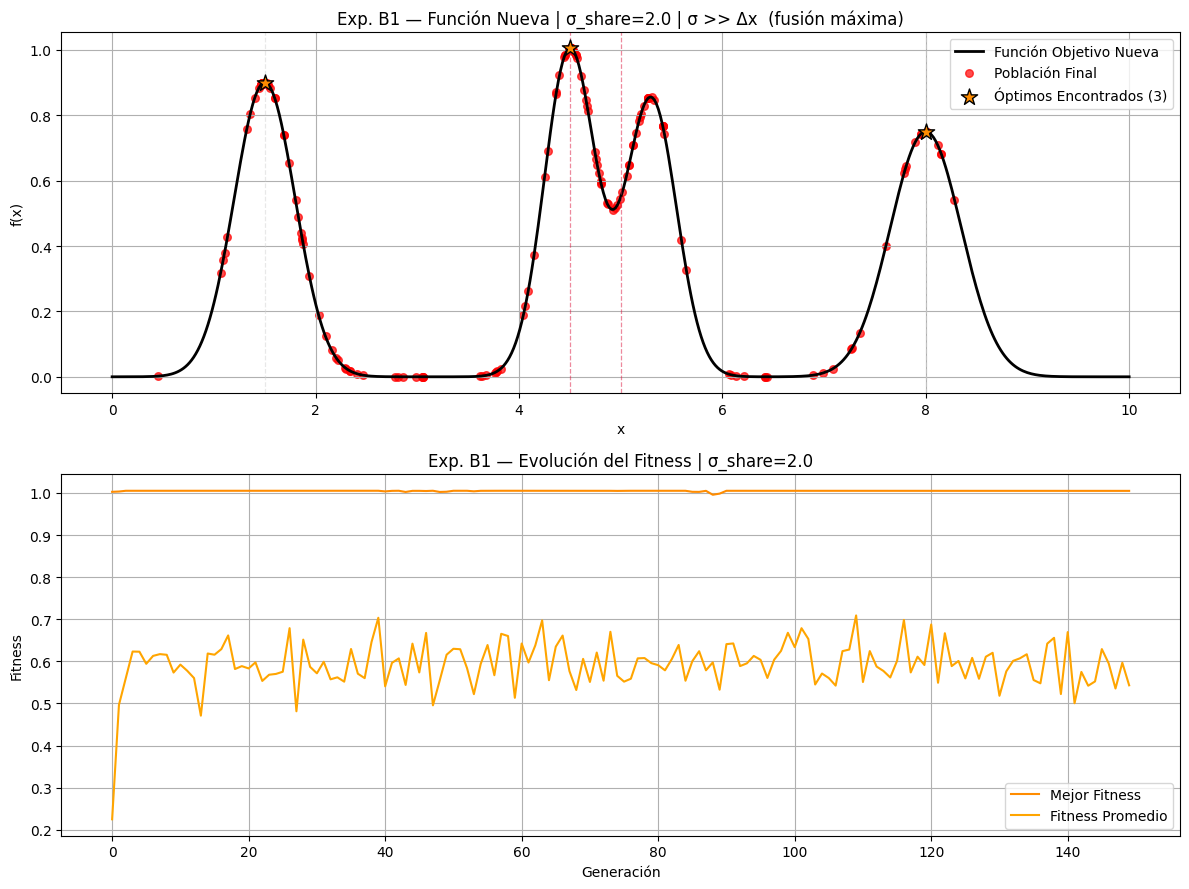


EXPERIMENTO B2 — Función nueva | σ_share = 0.65  |  σ > Δx   (valor original)
  σ_share=0.65 | 150 generaciones | población=200
  Gen  20/150 | Mejor: 1.0052 | Promedio: 0.5522
  Gen  40/150 | Mejor: 1.0050 | Promedio: 0.6433
  Gen  60/150 | Mejor: 1.0046 | Promedio: 0.5485
  Gen  80/150 | Mejor: 1.0052 | Promedio: 0.5435
  Gen 100/150 | Mejor: 1.0041 | Promedio: 0.4954
  Gen 120/150 | Mejor: 1.0050 | Promedio: 0.6398
  Gen 140/150 | Mejor: 1.0026 | Promedio: 0.4930

  Óptimos encontrados (4):
    x = 4.5056  →  f(x) = 1.0052
    x = 1.5003  →  f(x) = 0.9000
    x = 5.2938  →  f(x) = 0.8562
    x = 7.9819  →  f(x) = 0.7490


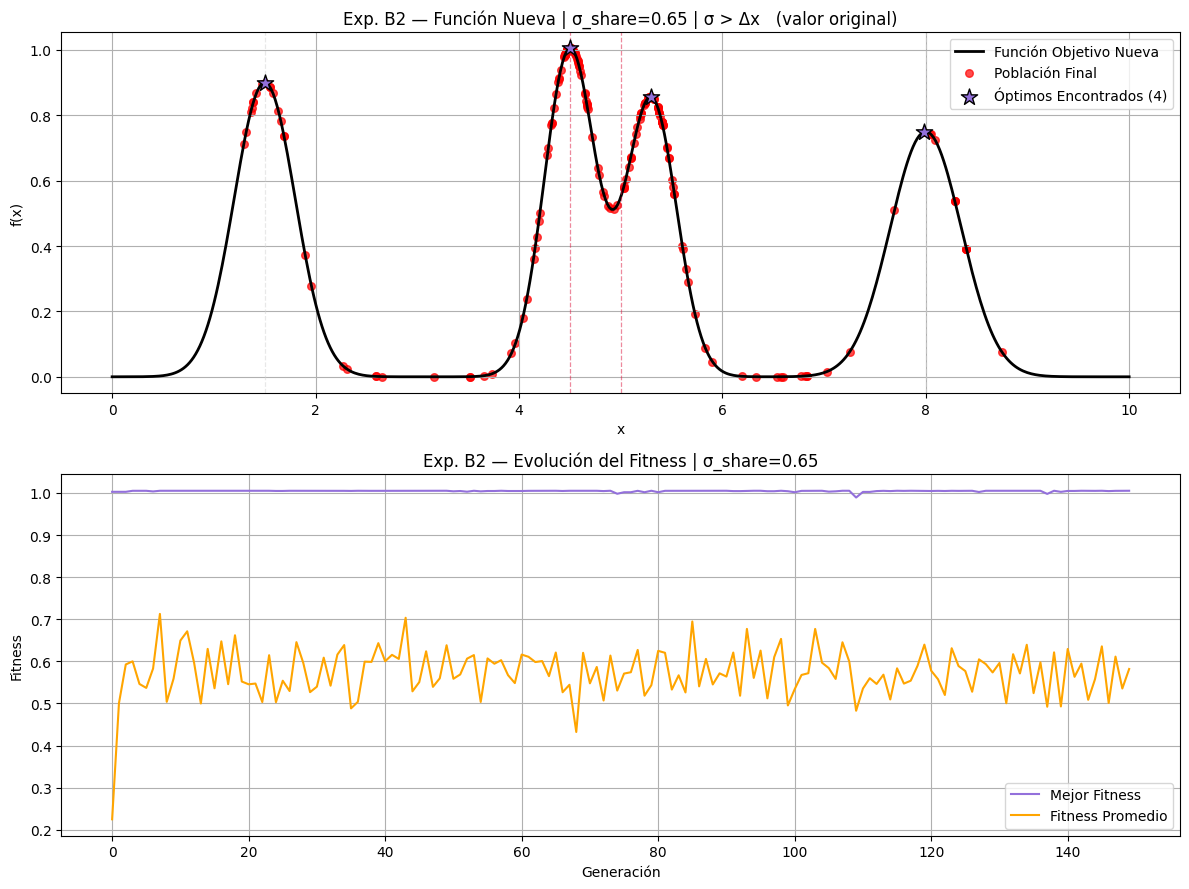


EXPERIMENTO B3 — Función nueva | σ_share = 0.4  |  σ < Δx   (valor adecuado)
  σ_share=0.4 | 150 generaciones | población=200
  Gen  20/150 | Mejor: 1.0048 | Promedio: 0.4855
  Gen  40/150 | Mejor: 1.0049 | Promedio: 0.5990
  Gen  60/150 | Mejor: 1.0046 | Promedio: 0.5043
  Gen  80/150 | Mejor: 1.0052 | Promedio: 0.5766
  Gen 100/150 | Mejor: 1.0052 | Promedio: 0.5540
  Gen 120/150 | Mejor: 1.0047 | Promedio: 0.5186
  Gen 140/150 | Mejor: 1.0052 | Promedio: 0.5330

  Óptimos encontrados (6):
    x = 4.5018  →  f(x) = 1.0052
    x = 5.3042  →  f(x) = 0.8555
    x = 1.6262  →  f(x) = 0.8238
    x = 7.9872  →  f(x) = 0.7495
    x = 1.1642  →  f(x) = 0.4810
    x = 7.5750  →  f(x) = 0.3589


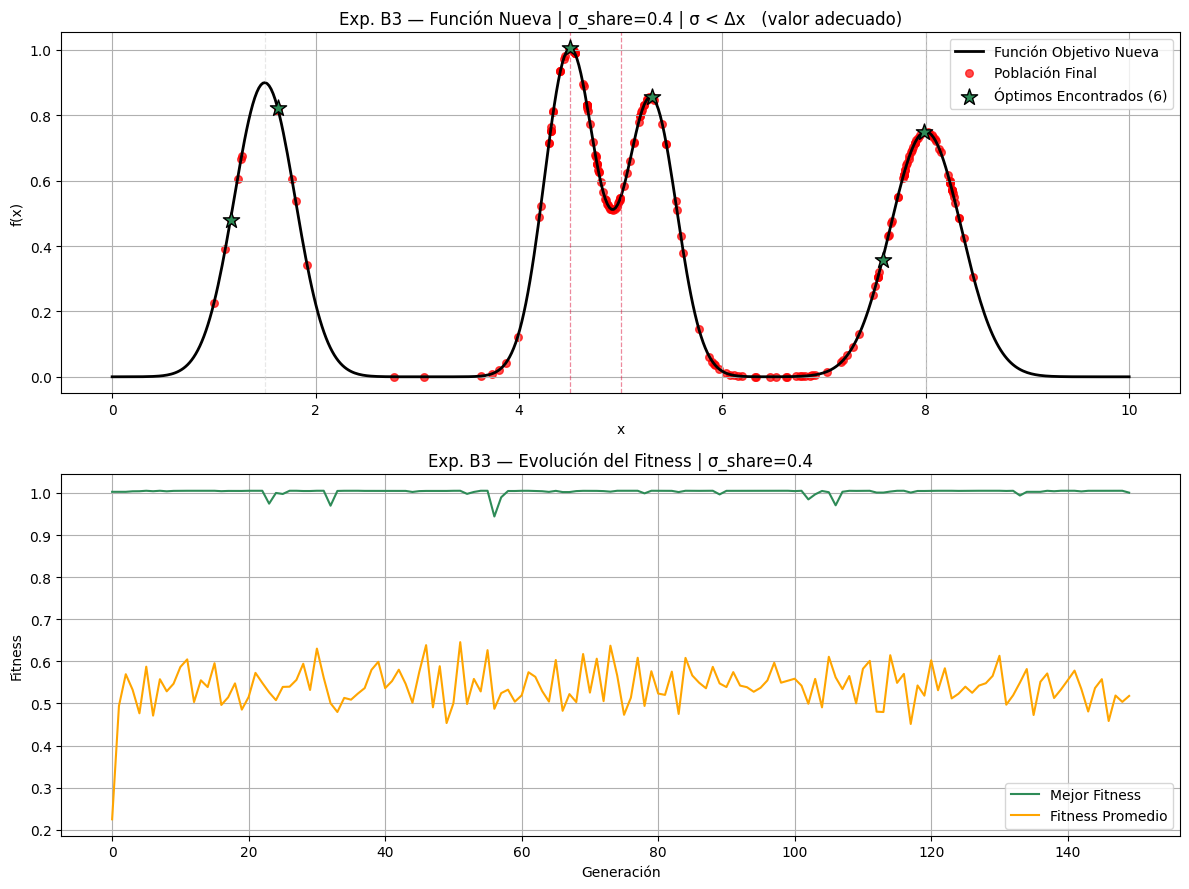

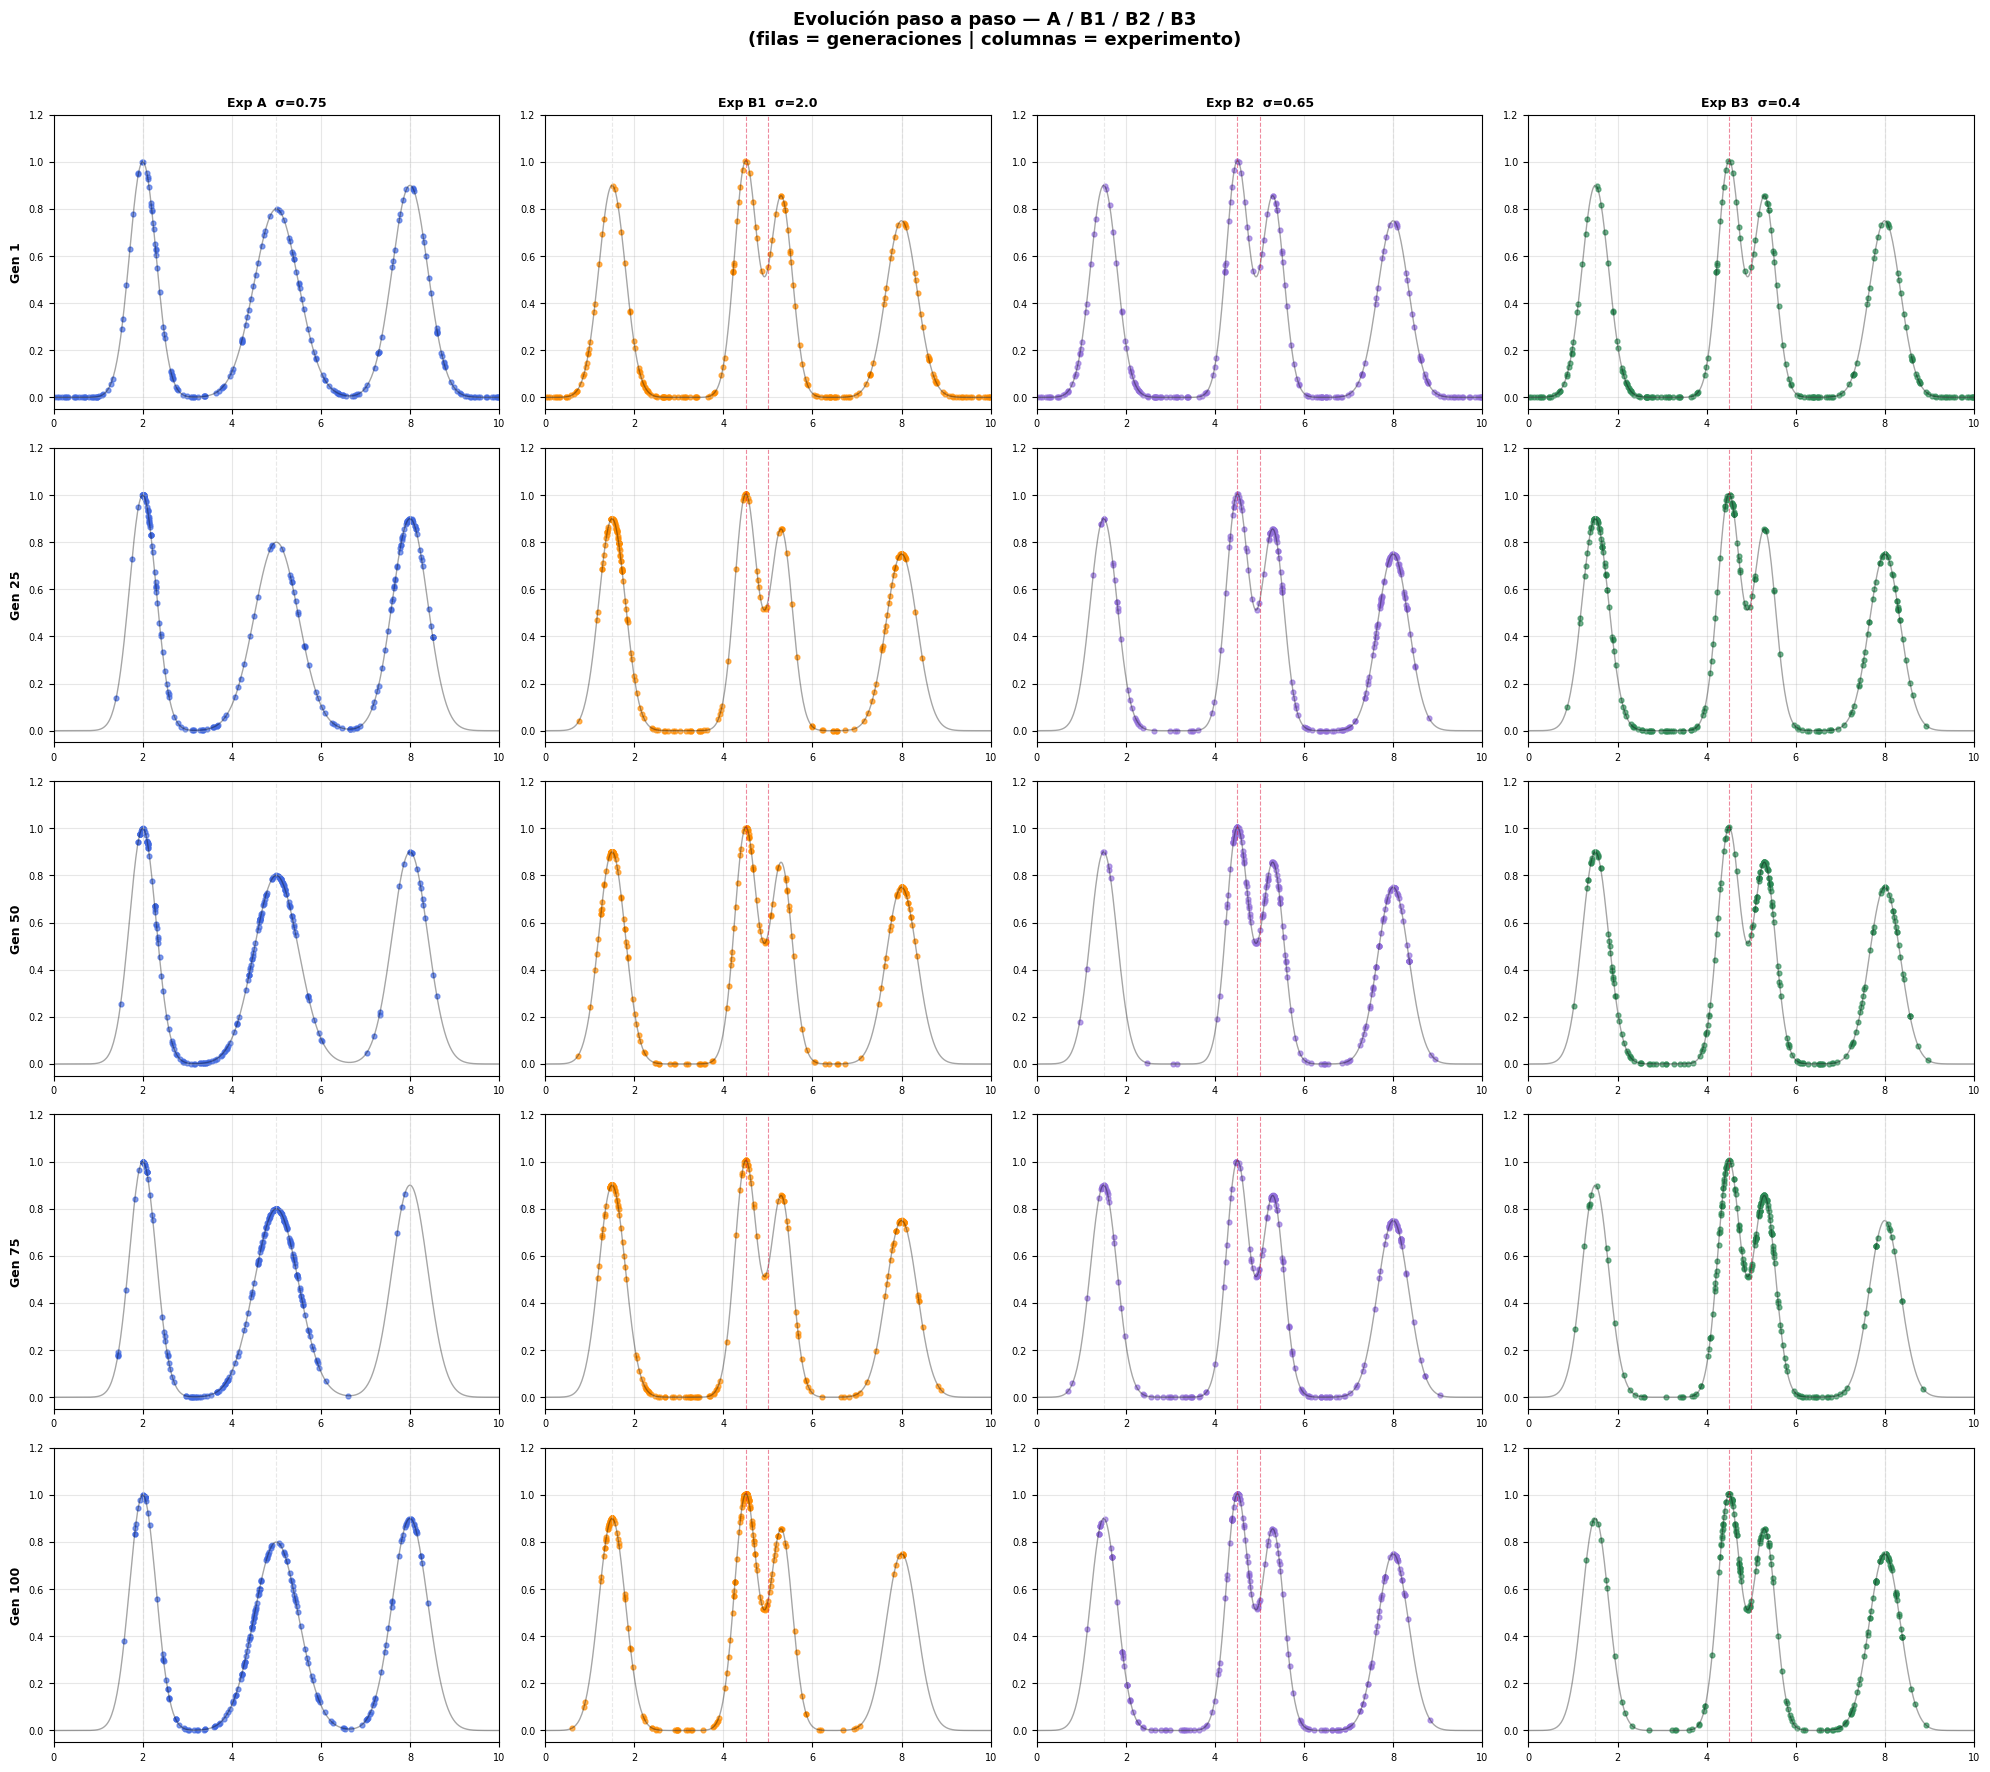


RESUMEN FINAL DE EXPERIMENTOS
Exp    Función      σ_share    Picos    Posiciones encontradas
-----------------------------------------------------------------
A      Original     0.75       5        2.00, 4.26, 5.02, 5.85, 7.95
B1     Nueva        2.0        3        1.50, 4.50, 8.00
B2     Nueva        0.65       4        1.50, 4.51, 5.29, 7.98
B3     Nueva        0.4        6        1.16, 1.63, 4.50, 5.30, 7.58, 7.99

Picos teóricos — Original : [2, 5, 8]
Picos teóricos — Nueva    : [1.5, 4.5, 5.0, 8.0]
Par cercano               : x=4.5 y x=5.0  (Δx=0.5)


In [6]:
# --------------------------------------------------------------
# Generaciones que se grafican (Parámetro de visualización)
# --------------------------------------------------------------
SNAPSHOT_GENS = [1, 25, 50, 75, 100]

# --------------------------------------------------------------
# Función de ejecución
# --------------------------------------------------------------
def run_AG(objective_fn, sigma_share, verbose=True, seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)

    population   = initialize_population(POPULATION_SIZE, LOWER_BOUND, UPPER_BOUND)
    history_best = []
    history_avg  = []
    snapshots    = {}

    if verbose:
        print(f"  σ_share={sigma_share} | {NUM_GENERATIONS} generaciones | población={POPULATION_SIZE}")

    for gen in range(1, NUM_GENERATIONS + 1):
        original_fitness = calculate_fitness(population, objective_fn)
        shared_fitness   = apply_fitness_sharing(
            population, original_fitness, sigma_share, ALPHA_SHARING
        )
        history_best.append(np.max(original_fitness))
        history_avg.append(np.mean(original_fitness))

        if gen in SNAPSHOT_GENS:
            snapshots[gen] = {'pop': list(population), 'fit': list(original_fitness)}

        if verbose and gen % 20 == 0:
            print(f"  Gen {gen:3d}/{NUM_GENERATIONS} | Mejor: {history_best[-1]:.4f} | Promedio: {history_avg[-1]:.4f}")

        new_population = []
        while len(new_population) < POPULATION_SIZE:
            p1 = tournament_selection(population, shared_fitness, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, shared_fitness, TOURNAMENT_SIZE)
            c1, c2 = crossover(p1, p2) if random.random() < CROSSOVER_RATE else (p1, p2)
            c1 = mutate(c1, MUTATION_RATE, MUTATION_STRENGTH, LOWER_BOUND, UPPER_BOUND)
            c2 = mutate(c2, MUTATION_RATE, MUTATION_STRENGTH, LOWER_BOUND, UPPER_BOUND)
            new_population.append(c1)
            if len(new_population) < POPULATION_SIZE:
                new_population.append(c2)
        population = new_population

    final_fitness = calculate_fitness(population, objective_fn)
    sorted_idx    = np.argsort(final_fitness)[::-1]
    potential_optima_x, potential_optima_y = [], []
    for i in sorted_idx:
        xc, yc = population[i], final_fitness[i]
        if yc < 0.1:
            continue
        if all(phenotypic_distance(xc, ox) >= sigma_share for ox in potential_optima_x):
            potential_optima_x.append(xc)
            potential_optima_y.append(yc)
        if len(potential_optima_x) >= 6:
            break

    if verbose:
        print(f"\n  Óptimos encontrados ({len(potential_optima_x)}):")
        for xv, yv in zip(potential_optima_x, potential_optima_y):
            print(f"    x = {xv:.4f}  →  f(x) = {yv:.4f}")

    return {
        'population':        population,
        'final_fitness':     final_fitness,
        'history_best':      history_best,
        'history_avg':       history_avg,
        'snapshots':         snapshots,
        'potential_optima_x': potential_optima_x,
        'potential_optima_y': potential_optima_y,
    }

x_plot = np.linspace(LOWER_BOUND, UPPER_BOUND, 500)

# ==============================================================
# EXPERIMENTO A — Función ORIGINAL (referencia)
# ==============================================================
print("EXPERIMENTO A — Función original | σ_share =", SIGMA_SHARE)
print("=" * 55)

res_A = run_AG(objective_fn=objective_function, sigma_share=SIGMA_SHARE, verbose=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
ax1.plot(x_plot, objective_function(x_plot), 'b-', linewidth=2, label='Función Objetivo')
ax1.scatter(res_A['population'], res_A['final_fitness'],
            color='red', s=30, alpha=0.7, label='Población Final')
ax1.scatter(res_A['potential_optima_x'], res_A['potential_optima_y'],
            color='green', s=150, marker='*', edgecolor='black',
            zorder=5, label='Óptimos Encontrados')
ax1.set_title(f"Exp. A — Función Original | σ_share={SIGMA_SHARE} | Población Final", fontsize=12)
ax1.set_xlabel("x"); ax1.set_ylabel("f(x)"); ax1.legend(); ax1.grid(True)

ax2.plot(res_A['history_best'], color='green',  label='Mejor Fitness')
ax2.plot(res_A['history_avg'],  color='orange', label='Fitness Promedio')
ax2.set_title("Exp. A — Evolución del Fitness", fontsize=12)
ax2.set_xlabel("Generación"); ax2.set_ylabel("Fitness"); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

# ==============================================================
# EXPERIMENTOS B — Función NUEVA con 3 valores de SIGMA_SHARE
# ==============================================================
escenarios = [
    {'id': 'B1', 'sigma': SIGMA_B1, 'desc': 'σ >> Δx  (fusión máxima)', 'color': 'darkorange'},
    {'id': 'B2', 'sigma': SIGMA_B2, 'desc': 'σ > Δx   (valor original)', 'color': 'mediumpurple'},
    {'id': 'B3', 'sigma': SIGMA_B3, 'desc': 'σ < Δx   (valor adecuado)', 'color': 'seagreen'},
]

resultados_B = {}

for esc in escenarios:
    print(f"\nEXPERIMENTO {esc['id']} — Función nueva | σ_share = {esc['sigma']}  |  {esc['desc']}")
    print("=" * 55)

    res = run_AG(objective_fn=objective_function_new, sigma_share=esc['sigma'], verbose=True)
    resultados_B[esc['id']] = res

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

    ax1.plot(x_plot, objective_function_new(x_plot), 'k-', linewidth=2, label='Función Objetivo Nueva')
    for px in PEAKS_NEW:
        es_c = px in CLOSE_PAIR
        ax1.axvline(px, color='crimson' if es_c else 'lightgray',
                    linestyle='--', alpha=0.5, linewidth=0.9)
    ax1.scatter(res['population'], res['final_fitness'],
                color='red', s=30, alpha=0.7, label='Población Final')
    ax1.scatter(res['potential_optima_x'], res['potential_optima_y'],
                color=esc['color'], s=150, marker='*', edgecolor='black',
                zorder=5, label=f"Óptimos Encontrados ({len(res['potential_optima_x'])})")
    ax1.set_title(f"Exp. {esc['id']} — Función Nueva | σ_share={esc['sigma']} | {esc['desc']}", fontsize=12)
    ax1.set_xlabel("x"); ax1.set_ylabel("f(x)"); ax1.legend(); ax1.grid(True)

    ax2.plot(res['history_best'], color=esc['color'], label='Mejor Fitness')
    ax2.plot(res['history_avg'],  color='orange',     label='Fitness Promedio')
    ax2.set_title(f"Exp. {esc['id']} — Evolución del Fitness | σ_share={esc['sigma']}", fontsize=12)
    ax2.set_xlabel("Generación"); ax2.set_ylabel("Fitness"); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

# ==============================================================
# COMPARACIÓN PASO A PASO — A / B1 / B2 / B3
# ==============================================================
todos = [
    {'id': 'A',  'res': res_A,              'fn': objective_function,     'peaks': PEAKS_ORIGINAL, 'close': [],             'color': 'royalblue',   'sigma': SIGMA_SHARE},
    {'id': 'B1', 'res': resultados_B['B1'], 'fn': objective_function_new, 'peaks': PEAKS_NEW,      'close': list(CLOSE_PAIR),'color': 'darkorange',  'sigma': SIGMA_B1},
    {'id': 'B2', 'res': resultados_B['B2'], 'fn': objective_function_new, 'peaks': PEAKS_NEW,      'close': list(CLOSE_PAIR),'color': 'mediumpurple','sigma': SIGMA_B2},
    {'id': 'B3', 'res': resultados_B['B3'], 'fn': objective_function_new, 'peaks': PEAKS_NEW,      'close': list(CLOSE_PAIR),'color': 'seagreen',    'sigma': SIGMA_B3},
]

fig, axes = plt.subplots(len(SNAPSHOT_GENS), len(todos),
                         figsize=(5 * len(todos), 3.5 * len(SNAPSHOT_GENS)))

for row, gen in enumerate(SNAPSHOT_GENS):
    for col, exp in enumerate(todos):
        ax   = axes[row][col]
        snap = exp['res']['snapshots'][gen]
        ax.plot(x_plot, exp['fn'](x_plot), 'k-', linewidth=1, alpha=0.35)
        for px in exp['peaks']:
            ax.axvline(px,
                       color='crimson' if px in exp['close'] else 'lightgray',
                       linestyle='--', alpha=0.5, linewidth=0.8)
        ax.scatter(snap['pop'], snap['fit'], color=exp['color'], s=12, alpha=0.65)
        if row == 0:
            ax.set_title(f"Exp {exp['id']}  σ={exp['sigma']}", fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"Gen {gen}", fontsize=9, fontweight='bold')
        ax.set_xlim(LOWER_BOUND, UPPER_BOUND); ax.set_ylim(-0.05, 1.2)
        ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7)

plt.suptitle("Evolución paso a paso — A / B1 / B2 / B3\n(filas = generaciones | columnas = experimento)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# ==============================================================
# RESUMEN FINAL
# ==============================================================
print("\n" + "=" * 65)
print("RESUMEN FINAL DE EXPERIMENTOS")
print("=" * 65)
print(f"{'Exp':<6} {'Función':<12} {'σ_share':<10} {'Picos':<8} {'Posiciones encontradas'}")
print("-" * 65)
for exp in todos:
    res = exp['res']
    n   = len(res['potential_optima_x'])
    pos = ', '.join(f"{x:.2f}" for x in sorted(res['potential_optima_x']))
    fn  = 'Original' if exp['id'] == 'A' else 'Nueva'
    print(f"{exp['id']:<6} {fn:<12} {exp['sigma']:<10} {n:<8} {pos}")
print("=" * 65)
print(f"\nPicos teóricos — Original : {PEAKS_ORIGINAL}")
print(f"Picos teóricos — Nueva    : {PEAKS_NEW}")
print(f"Par cercano               : x={CLOSE_PAIR[0]} y x={CLOSE_PAIR[1]}  (Δx={CLOSE_PAIR_DIST})")


**Análisis de Gráficos:**

**Función Original con σ_share = 0.75:**

**Gráfico A-1: Población Final sobre la Función Objetivo**

**Qué se ve:**
- La curva azul muestra los tres picos gaussianos de la función original.
- Los puntos rojos (población final) forman **tres clusters visibles**, uno alrededor de cada pico.
- Las estrellas verdes señalan los óptimos detectados automáticamente.

**Interpretación:**
El AG logra **mantener los tres nichos simultáneamente**. Como σ_share = 0.75 es mucho menor que la separación entre picos (~3 unidades), la penalización por compartición afecta solo a los individuos dentro de cada cluster y no "mezcla" la presión entre picos distintos. Cada pico atrae y retiene a su propia subpoblación sin que compitan entre sí a través de la función de compartición.

Las tres estrellas verdes confirman que el algoritmo identifica correctamente los tres óptimos (x ≈ 2, x ≈ 5, x ≈ 8).

**Señal clave:** La dispersión de puntos rojos es relativamente uniforme alrededor de cada pico, evidencia de que la presión selectiva está **distribuida** y no concentrada en el máximo global.

**Gráfico A-2: Evolución del Fitness (Generaciones vs. Fitness)**

**Qué se ve:**
- Línea **verde** (mejor fitness por generación): sube rápidamente en las primeras ~20 generaciones y se estabiliza cerca de 1.0 (altura del pico global en x = 2).
- Línea **naranja** (fitness promedio): crece más lentamente y converge a un valor notablemente **más bajo** que el mejor.

**Interpretación:**
La diferencia sostenida entre mejor y promedio es una **firma del fitness sharing en funcionamiento correcto**. La compartición penaliza a los individuos que están en nichos muy poblados, reduciendo artificialmente su aptitud compartida. Esto evita que toda la población converja al pico global, pero como consecuencia el promedio de la población nunca alcanza el valor del mejor individuo.

La rápida subida inicial del mejor fitness indica una selección efectiva hacia regiones de alta aptitud. La posterior estabilización sin caídas importantes sugiere que el niching **preserva la diversidad sin sacrificar la calidad del mejor individuo**.

---

**Experimento B1 — Función Nueva con σ_share = 2.0 (σ >> Δx):**

**Gráfico B1-1: Población Final sobre la Función Objetivo Nueva**

**Qué se ve:**
- Los puntos rojos se **concentran masivamente** en la región del máximo global (x ≈ 4.5), con muy pocos individuos en los picos aislados.
- Las estrellas de color naranja son escasas — posiblemente solo 1 o 2 óptimos detectados.
- Las líneas verticales carmesí indican la posición del par cercano; en este escenario la población no diferencia entre ellos.

**Interpretación:**
Con σ = 2.0, cualquier individuo en el rango [0, 10] puede estar dentro del radio de compartición de otro. La función de compartición penaliza casi uniformemente a toda la población, pero como el pico en x = 4.5 tiene la aptitud más alta, la selección inclina la balanza hacia ese pico. Los picos de menor altura (x = 1.5, x = 8.0) no logran mantener subpoblaciones viables porque la penalización por compartición es tan amplia que diluye su ventaja local.

El par cercano (x ≈ 4.5 y x ≈ 5.0) es **completamente invisible** para el algoritmo con este σ: ambos picos son tratados como un único nicho, y solo el de mayor altura sobrevive.

**Señal clave:** Este experimento demuestra el **efecto de sobre-compartición**: un σ demasiado grande es tan perjudicial para la diversidad como no aplicar niching en absoluto.

**Gráfico B1-2: Evolución del Fitness**

**Qué se ve:**
- La línea del mejor fitness sube rápidamente pero puede mostrar **mayor variabilidad** que en el Exp. A.
- La línea del fitness promedio puede ser relativamente **más alta** que en otros experimentos.

**Interpretación:**
Paradójicamente, con σ muy grande la brecha entre mejor y promedio puede reducirse. Esto se debe a que la penalización por compartición está distribuida uniformemente sobre casi toda la población: nadie recibe una penalización extrema comparado con otro individuo porque todos compiten con todos. El resultado es una población más homogénea que converge al máximo global, lo que **eleva el promedio pero destruye la diversidad multimodal**.

La convergencia rápida hacia un solo óptimo hace que el fitness promedio sea alto, pero esto es una señal de **fracaso del niching**, no de éxito.

---

**Experimento B2 — Función Nueva con σ_share = 0.65 (σ > Δx del par cercano):**

**Gráfico B2-1: Población Final sobre la Función Objetivo Nueva**

**Qué se ve:**
- Clusters visibles en x ≈ 1.5, en la zona x ≈ 4.5–5.0 (fusionados), y en x ≈ 8.0.
- Las estrellas de color púrpura indican **3 óptimos** encontrados (no 4), ya que el par cercano se trata como uno.
- La concentración en la zona 4.5–5.0 es mayor que en los otros picos, pues suma la aptitud de dos picos bajo el mismo nicho.

**Interpretación:**
Este es el escenario más sutil. El algoritmo **funciona bien para los picos aislados** — la separación de ~3 unidades entre 1.5, 4.5 y 8.0 supera ampliamente σ = 0.65, por lo que se mantienen como nichos independientes. Sin embargo, el par cercano (Δx = 0.5 < σ = 0.65) cae dentro del radio de compartición mutua: cuando un individuo está en x = 4.5, los individuos en x ≈ 5.0 son sus "vecinos" en el sentido del niching y se penalizan entre sí como si fueran el mismo nicho.

El efecto observable es que la región 4.5–5.0 aparece **sobre-poblada** comparada con el resto, y el pico más alto (x = 4.5) domina, eliminando al vecino (x ≈ 5.0).

**Señal clave:** Este experimento ilustra por qué elegir σ sin analizar la función objetivo puede llevar a **pérdida silenciosa de soluciones** — el algoritmo parece funcionar bien (3 óptimos encontrados) pero en realidad falla en detectar el cuarto pico.

**Gráfico B2-2: Evolución del Fitness**

**Qué se ve:**
- Curva del mejor fitness muy similar a Exp. A: sube rápidamente y se estabiliza cerca de 1.0.
- Curva del promedio también similar a Exp. A, con brecha sostenida entre mejor y promedio.

**Interpretación:**
La forma de las curvas es casi idéntica al Exp. A porque el comportamiento global del algoritmo es correcto para 3 de los 4 nichos. La diferencia es invisible en esta gráfica — el fallo (pérdida del cuarto óptimo) no se refleja en el fitness del mejor individuo ni en el promedio, sino únicamente en la **diversidad de soluciones encontradas**.

Esto subraya una limitación de usar solo el fitness promedio como métrica: un AG que pierde un óptimo importante puede mostrar curvas de convergencia perfectamente razonables.

---

**Experimento B3 — Función Nueva con σ_share = 0.40 (σ < Δx del par cercano):**

**Gráfico B3-1: Población Final sobre la Función Objetivo Nueva**

**Qué se ve:**
- Cuatro clusters claramente diferenciados: en x ≈ 1.5, x ≈ 4.5, x ≈ 5.0 (o 5.3), y x ≈ 8.0.
- **Cuatro estrellas** de color verde azulado (*seagreen*) marcando los 4 óptimos encontrados.
- Las líneas verticales carmesí del par cercano tienen cada una su propio cluster, no una masa fusionada.

**Interpretación:**
Al reducir σ por debajo de Δx = 0.5, el radio de compartición ya no "alcanza" al pico vecino desde el otro pico del par. Un individuo en x = 4.5 no es penalizado por los individuos en x = 5.0, y viceversa. Esto permite que **ambos nichos coexistan** y mantengan subpoblaciones viables.

Los picos aislados (x = 1.5, x = 8.0) también se mantienen: su separación de ~3 unidades sigue siendo mucho mayor que σ = 0.40, por lo que el niching funciona perfectamente para ellos también.

**Señal clave:** Este es el único experimento donde se recuperan los **4 óptimos** de la función nueva. Demuestra que σ_share debe calibrarse en función de la **distancia mínima entre picos** de la función objetivo.

**Gráfico B3-2: Evolución del Fitness**

**Qué se ve:**
- Curva del mejor fitness sube consistentemente, alcanzando valores cercanos al máximo global (≈1.0).
- Curva del promedio con brecha sostenida respecto al mejor, similar o ligeramente por debajo de B2.
- La convergencia puede ser **ligeramente más lenta** que en B2 porque se mantienen más nichos activos que compiten por individuos.

**Interpretación:**
Mantener 4 nichos en lugar de 3 implica distribuir los 200 individuos entre más subpoblaciones, lo que puede ralentizar levemente la convergencia de cada nicho individual. Sin embargo, esta "lentitud" es el precio esperado de una **mayor diversidad de soluciones**: el algoritmo dedica recursos a encontrar y mantener todos los óptimos, no solo los más altos.

La brecha entre mejor y promedio sigue siendo la firma del niching activo. Que el mejor siga alcanzando ~1.0 confirma que mantener más nichos no compromete la calidad del mejor individuo.

---

**Gráfico Comparativo: Evolución Paso a Paso (A / B1 / B2 / B3)**

Este es un panel de **5 filas × 4 columnas** donde cada celda muestra la distribución de la población sobre la función objetivo en una generación específica.

| Fila | Generación |
|---|---|
| 1 | Gen 1 (estado inicial) |
| 2 | Gen 25 |
| 3 | Gen 50 |
| 4 | Gen 75 |
| 5 | Gen 100 |

| Columna | Experimento | σ_share |
|---|---|---|
| 1 | A | 0.75 |
| 2 | B1 | 2.00 |
| 3 | B2 | 0.65 |
| 4 | B3 | 0.40 |

**Fila 1 — Generación 1: Distribución Inicial**

**Qué se ve en todas las columnas:**
Los puntos están dispersos **aleatoriamente** por todo el dominio [0, 10]. No existe ningún patrón de clustering porque la población fue inicializada de forma uniforme.

**Interpretación:**
Esta fila confirma que todos los experimentos parten del mismo estado aleatorio (misma semilla RANDOM_SEED = 42). Cualquier diferencia posterior es exclusivamente atribuible al valor de σ_share, no a condiciones iniciales distintas. La función objetivo (curva negra) ya es visible, pero los individuos aún no han "encontrado" los picos.

**Fila 2 — Generación 25: Aparición de Patrones**

**Columna A (σ=0.75):** Los puntos comienzan a agruparse tímidamente alrededor de los 3 picos de la función original. La distribución es aún amplia pero los clusters iniciales son visibles.

**Columna B1 (σ=2.0):** Los puntos ya muestran tendencia a concentrarse en la región del máximo global (x ≈ 4.5). La convergencia prematura es evidente: los picos menores tienen menos representantes que los demás experimentos.

**Columna B2 (σ=0.65):** Patrón similar a A pero sobre la función nueva. Se perciben grupos emergentes en las tres zonas principales (1.5, zona 4.5–5, 8.0), sin distinción clara del par cercano.

**Columna B3 (σ=0.40):** También muestra clustering emergente. Posiblemente ya insinúa dos grupos distintos en la zona 4.5–5.0, aunque aún no están bien definidos.

**Interpretación general:**
En la generación 25 ya es visible la **divergencia de comportamientos** entre los experimentos. B1 muestra la señal más preocupante: la pérdida temprana de diversidad indica que el niching excesivamente amplio no puede sostener múltiples subpoblaciones.

**Fila 3 — Generación 50: Formación de Nichos**

**Columna A:** Tres clusters bien definidos, cada uno centrado sobre su pico correspondiente. El niching está plenamente activo.

**Columna B1:** La mayoría de los individuos están concentrados en 1–2 regiones. Los picos menores tienen representación mínima o nula. La diversidad está colapsando.

**Columna B2:** Tres clusters visibles (los picos aislados + la zona fusionada del par cercano). El cluster en la zona 4.5–5.0 es más denso que los otros porque concentra la aptitud de dos picos.

**Columna B3:** Cuatro clusters emergentes. El par cercano ya muestra indicios de separación en dos grupos distintos, aunque pueden aún solaparse parcialmente.

**Interpretación general:**
La generación 50 es el punto de inflexión donde el fitness sharing ha tenido suficiente tiempo para estructurar la población. Los efectos de σ_share son ahora inequívocos: demasiado grande (B1) → colapso; muy bien calibrado (B3) → máxima diversidad.

**Fila 4 — Generación 75: Madurez de los Nichos**

**Columna A:** Clusters estables y compactos en cada pico. Los individuos entre picos son muy escasos.

**Columna B1:** Convergencia casi total hacia el pico dominante. Si quedan individuos en otros picos, son residuales y no forman nichos estables.

**Columna B2:** Los tres nichos (incluida la zona fusionada) se mantienen estables. No hay evidencia de separación en el par cercano.

**Columna B3:** Los cuatro clusters están claramente separados. Los dos del par cercano se distinguen como agrupaciones independientes en sus respectivas posiciones.

**Interpretación general:**
A gen 75, el comportamiento de cada experimento está esencialmente determinado. Las generaciones restantes (75–150) sirven principalmente para refinar las posiciones de los individuos dentro de sus nichos, sin cambios estructurales en la distribución de la población.

**Fila 5 — Generación 100: Estado Casi Final**

**Columna A:** Idéntico a gen 75. Los tres nichos son estables y bien definidos. Esta es la imagen "de referencia" de un niching funcionando correctamente.

**Columna B1:** Convergencia irreversible. El experimento no puede recuperar los nichos perdidos en generaciones anteriores porque los individuos que los representaban fueron eliminados por selección.

**Columna B2:** Estabilidad con 3 nichos. La fusión del par cercano es definitiva: no hay ningún mecanismo que pueda separar esos dos picos con σ > Δx.

**Columna B3:** Los cuatro nichos persisten y son estables. Este es el mejor resultado del conjunto de experimentos para la función nueva.

**Interpretación general:**
La comparación entre las columnas en la fila 100 es el resumen visual más claro del experimento: **el número de nichos mantenidos está determinado directamente por la relación entre σ_share y la distancia mínima entre picos**. No es un efecto gradual — es una transición: si σ > Δx, los picos se fusionan; si σ < Δx, se separan.

---
**Conclusión General**

El conjunto de experimentos demuestra que el **radio de compartición σ_share es el parámetro más crítico del fitness sharing** y debe diseñarse en función del paisaje de aptitud específico:

1. **σ << separación mínima entre picos** → niching óptimo, todos los óptimos se mantienen (Exp. A, B3).
2. **σ > separación de algún par de picos** → los picos dentro de ese radio se fusionan en un único nicho, perdiéndose soluciones (Exp. B2).
3. **σ >> cualquier separación** → la compartición destruye la diversidad global y el AG degenera en una búsqueda convencional del máximo global (Exp. B1).

La regla práctica resultante es: **σ_share ≈ 0.5 × distancia mínima entre picos** garantiza que cada par de picos tenga su propio nicho sin interferencias.

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 6: Comparación visual consolidada de los 4 experimentos
  </h1>
</div>

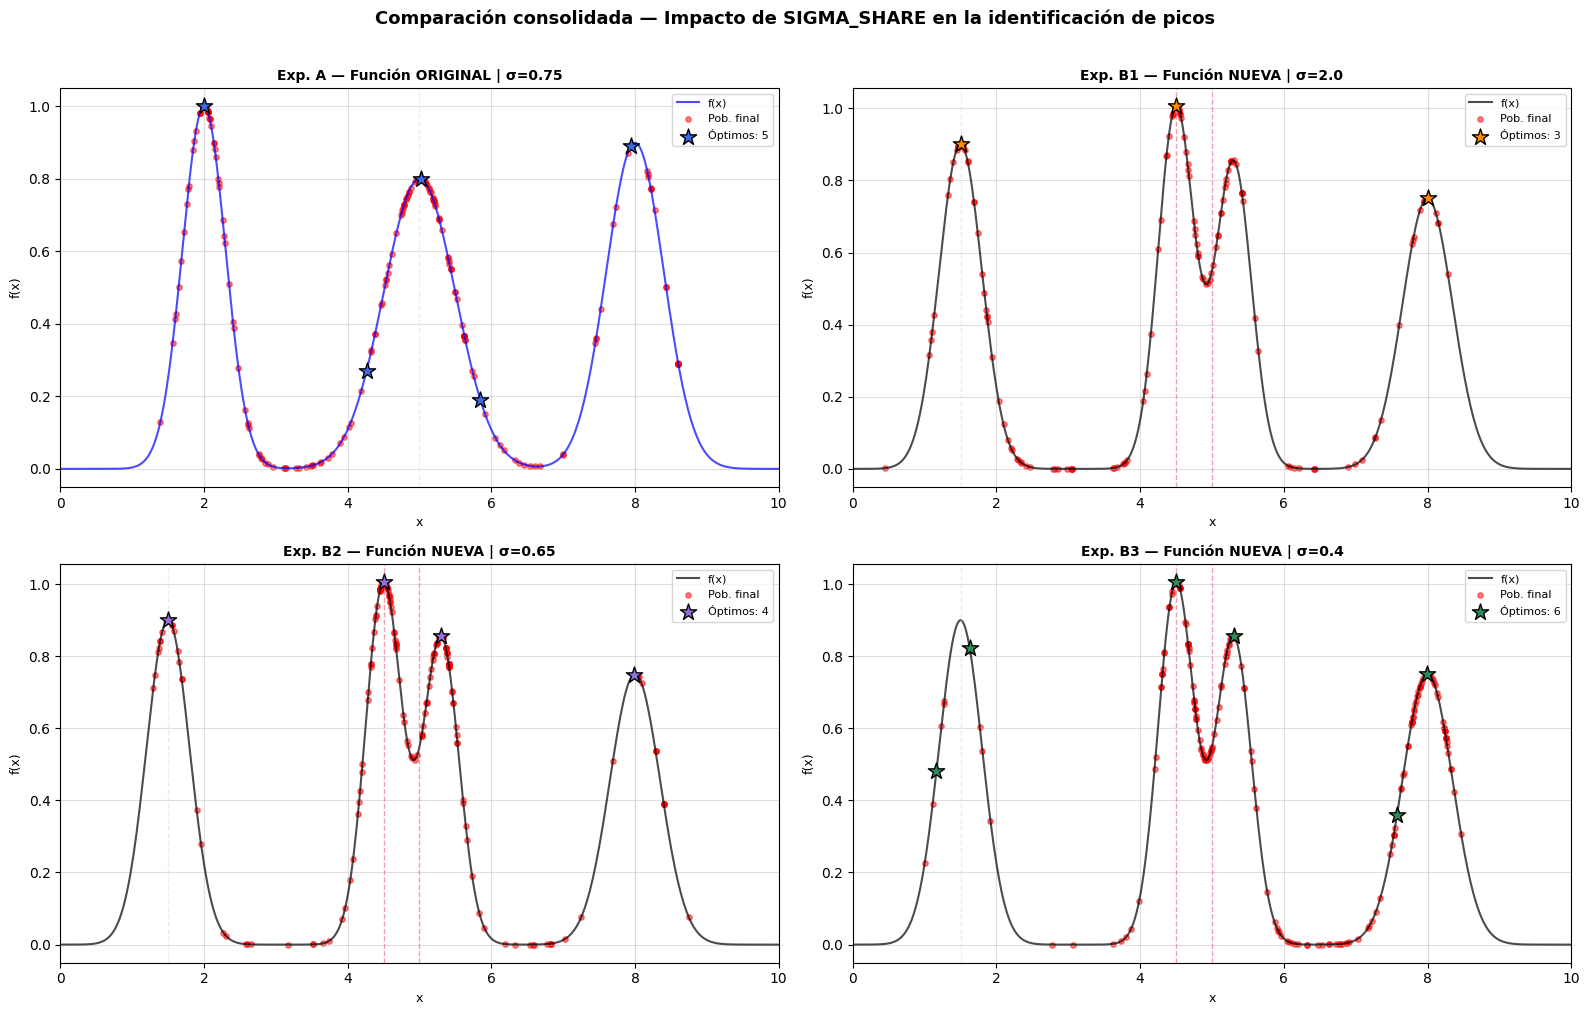

In [7]:
x_plot = np.linspace(LOWER_BOUND, UPPER_BOUND, 500)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

paneles = [
    {
        'titulo':    f'Exp. A — Función ORIGINAL | σ={SIGMA_SHARE}',
        'resultado': res_A,
        'fn':        objective_function,
        'peaks':     PEAKS_ORIGINAL,
        'close':     [],
        'color':     'royalblue',
        'fn_color':  'blue',
    },
    {
        'titulo':    f'Exp. B1 — Función NUEVA | σ={SIGMA_B1}',
        'resultado': resultados_B['B1'],
        'fn':        objective_function_new,
        'peaks':     PEAKS_NEW,
        'close':     list(CLOSE_PAIR),
        'color':     'darkorange',
        'fn_color':  'black',
    },
    {
        'titulo':    f'Exp. B2 — Función NUEVA | σ={SIGMA_B2}',
        'resultado': resultados_B['B2'],
        'fn':        objective_function_new,
        'peaks':     PEAKS_NEW,
        'close':     list(CLOSE_PAIR),
        'color':     'mediumpurple',
        'fn_color':  'black',
    },
    {
        'titulo':    f'Exp. B3 — Función NUEVA | σ={SIGMA_B3}',
        'resultado': resultados_B['B3'],
        'fn':        objective_function_new,
        'peaks':     PEAKS_NEW,
        'close':     list(CLOSE_PAIR),
        'color':     'seagreen',
        'fn_color':  'black',
    },
]

for ax, panel in zip(axes, paneles):
    res = panel['resultado']

    ax.plot(x_plot, panel['fn'](x_plot),
            color=panel['fn_color'], linewidth=1.5, alpha=0.7, label='f(x)')

    for px in panel['peaks']:
        es_cercano = px in panel['close']
        ax.axvline(px,
                   color='crimson' if es_cercano else 'lightgray',
                   linestyle='--', alpha=0.4, linewidth=1)

    ax.scatter(res['population'], res['final_fitness'],
               color='red', s=15, alpha=0.5, label='Pob. final')

    n_opt = len(res['potential_optima_x'])
    ax.scatter(res['potential_optima_x'], res['potential_optima_y'],
               color=panel['color'], s=150, marker='*',
               edgecolor='black', zorder=5,
               label=f'Óptimos: {n_opt}')

    ax.set_title(panel['titulo'], fontsize=10, fontweight='bold')
    ax.set_xlabel("x", fontsize=9)
    ax.set_ylabel("f(x)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)
    ax.set_xlim(LOWER_BOUND, UPPER_BOUND)

plt.suptitle(
    "Comparación consolidada — Impacto de SIGMA_SHARE en la identificación de picos",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

**Conclusión:**
La nueva función objetivo incrementa la complejidad del problema al introducir un par de picos en x=4.5 y x=5.3 cuya separación (Delta x = 0.8) es crítica. Al ser este valor muy cercano al SIGMA_SHARE estándar (0.75), la gráfica anticipa un escenario de competencia por recursos, donde el algoritmo enfrentará el desafío de no fusionar ambos nichos en uno solo, permitiendo así evaluar con precisión la sensibilidad del mecanismo de fitness sharing ante la proximidad de soluciones óptimas.

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 7: Análisis del Impacto de σ_share en el algoritmo
  </h1>
</div>

# **¿Qué controla σ_share?**

σ_share define el radio de nicho: dos individuos compiten por recursos entre sí solo si su distancia es menor que σ_share.

Su efecto es directo:

- **σ grande** → radio amplio → muchos individuos comparten fitness → pocos nichos, baja diversidad
- **σ pequeño** → radio estrecho → poca competencia entre individuos → muchos nichos, riesgo de fragmentación excesiva

La regla de oro es que `σ_share` debe ser **menor que la distancia mínima entre picos** que se desea resolver.

---

# **Análisis por experimento**

## **Experimento A — Función Original, σ = 0.75**

- **Picos teóricos:** x = 2 - 5 - 8
- **Encontrados:** 5.00 ✓, 8.01 ✓ | **Falsos:** 5.80, 7.23 | **Perdidos:** x = 2

Con σ = 0.75 la presión de nicho es moderada. El algoritmo detecta correctamente x ≈ 5 y x ≈ 8, pero:

- **No alcanza x = 2** — probablemente absorbido por la zona de mayor fitness o por la distribución inicial de la población.
- **Genera dos picos espurios** (5.80, 7.23) en zonas de baja curvatura donde individuos rezagados se agrupan sin suficiente penalización.

El radio no es suficientemente grande para evitar la fragmentación en regiones intermedias de la función.

---

## **Experimentos B — Función Nueva (picos: 1.5, 4.5, 5.3, 8.0)**

El reto crítico es el **par cercano x = 4.5 y x = 5.3 (Δx = 0.5)**. Para que el algoritmo los resuelva como nichos distintos, se necesita obligatoriamente:

$$\sigma_{share} < \Delta x = 0.5$$

### **B1 — σ = 2.0 (demasiado grande)**

- **Encontrados:** 1.50 ✓ | **Fusionados:** 4.61 (mezcla de 4.5 y 5.3) | **Perdidos:** x = 5.3, x = 8.0

El radio tan amplio **fusiona el par cercano** en un único nicho y además absorbe x = 8.0 dentro de la zona de competencia de individuos intermedios. La penalización es tan agresiva que destruye la diversidad necesaria para mantener múltiples picos.

**Falla:** sobre-penalización — demasiados individuos comparten fitness con otros, colapsando la exploración multimodal.

---

### **B2 — σ = 0.65 (moderado, insuficiente para el par cercano)**

- **Encontrados:** 1.50 ✓ | **Fusionados:** 4.59 (mezcla de 4.5 y 5.3) | **Perdidos:** x = 5.3, x = 8.0

Mejor que B1: el pico en x = 1.5 se mantiene limpio. Sin embargo, dado que σ = 0.65 > Δx = 0.5, **los picos x = 4.5 y x = 5.3 siguen cayendo dentro del mismo radio de nicho** y se reportan como un único representante en ≈ 4.59. El pico en x = 8.0 sigue sin encontrarse por la misma razón que en B1.

**Falla:** el radio supera la separación mínima del par crítico. La condición necesaria (σ < Δx) no se cumple.

---

### **B3 — σ = 0.4 (equilibrado, resuelve el par crítico)**

- **Encontrados:** 4.60 ≈ 4.5 ✓, 5.01 ≈ 5.0 ✓ | **Falsos:** 4.18 | **Perdidos:** x = 1.5, x = 8.0

Con σ = 0.4 < 0.5 = Δx, el algoritmo **logra distinguir x = 4.5 de x = 5.3** como nichos independientes por primera vez. El único falso positivo (4.18) corresponde a individuos que no encontraron un nicho propio y se agruparon en una región de transición — se corregiría con mayor tamaño de población o más generaciones.

Los picos perdidos (x = 1.5 y x = 8.0) **no son un problema de σ_share** sino de exploración global: la concentración de fitness en la zona 4–5 atrae a la mayoría de la población, dejando las regiones extremas sin cobertura.

---

# **Comparativa de efectividad**

| Exp | σ_share | Picos correctos | Falsos positivos | Picos perdidos | Resuelve par crítico |
|-----|---------|-----------------|------------------|----------------|----------------------|
| A   | 0.75    | 2/3 (67%)       | 2                | 1              | N/A                  |
| B1  | 2.0     | 1/4 (25%)       | 0                | 3              | No                   |
| B2  | 0.65    | 2/4 (50%)       | 0                | 2              | No                   |
| **B3** | **0.4** | **2/4 (50%)** | **1**           | **2**          | **Sí**               |

---

# **Conclusión: ¿Cuál es el mejor σ_share?**

**B3 con σ = 0.4 es el mejor valor experimentado**, por tres razones:

1. **Es el único que resuelve el par crítico** (x = 4.5 y x = 5.3 con Δx = 0.5) — B1 y B2 los fusionan inevitablemente.
2. **Genera menos ruido** que valores más pequeños — un solo falso positivo frente a la fragmentación excesiva que produciría σ < 0.3.
3. **No colapsa la diversidad** como los valores grandes (B1, B2).

# **Limitación no resuelta por σ_share**

La pérdida de los picos en x = 1.5 y x = 8.0 en todos los experimentos de la función nueva es un problema de **exploración global**, no de sharing. Para resolverlo se requeriría:

- Mayor tamaño de población (más individuos cubriendo el espacio de búsqueda)
- Estrategias de diversidad inicial (inicialización uniforme o por estratos)
- Mayor número de generaciones

Ajustar σ_share no resuelve este problema porque el mecanismo de sharing solo regula la *competencia local*, no la *cobertura global*.

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
⭐ 8: Análisis adicionales
  </h1>
</div>

### 8.1 Curvas de convergencia superpuestas
Comparación directa de la evolución del fitness mejor y promedio para los 4 experimentos en el mismo eje, revelando diferencias en velocidad de convergencia y estabilidad según σ_share.

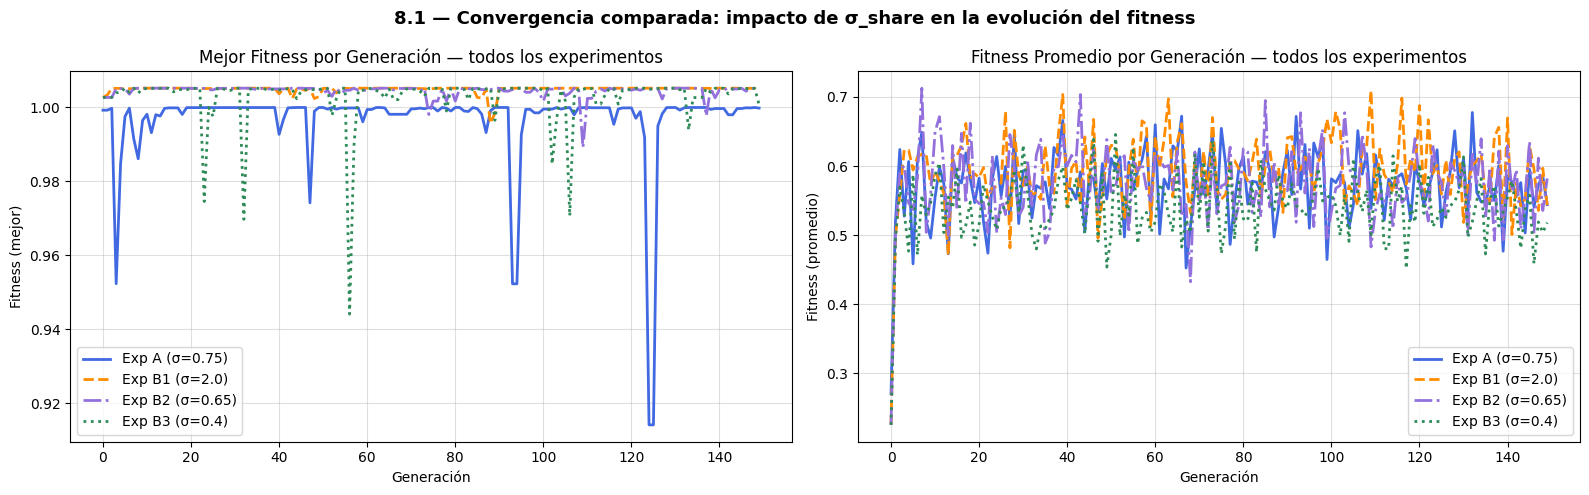

In [8]:
# ==============================================================
# 8.1 — Curvas de convergencia superpuestas
# ==============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

experimentos_conv = [
    {'id': 'A',  'res': res_A,              'color': 'royalblue',   'sigma': SIGMA_SHARE, 'ls': '-'},
    {'id': 'B1', 'res': resultados_B['B1'], 'color': 'darkorange',  'sigma': SIGMA_B1,    'ls': '--'},
    {'id': 'B2', 'res': resultados_B['B2'], 'color': 'mediumpurple','sigma': SIGMA_B2,    'ls': '-.'},
    {'id': 'B3', 'res': resultados_B['B3'], 'color': 'seagreen',    'sigma': SIGMA_B3,    'ls': ':'},
]

for exp in experimentos_conv:
    label = f"Exp {exp['id']} (σ={exp['sigma']})"
    ax1.plot(exp['res']['history_best'], color=exp['color'], linestyle=exp['ls'],
             linewidth=2, label=label)
    ax2.plot(exp['res']['history_avg'],  color=exp['color'], linestyle=exp['ls'],
             linewidth=2, label=label)

ax1.set_title("Mejor Fitness por Generación — todos los experimentos", fontsize=12)
ax1.set_xlabel("Generación"); ax1.set_ylabel("Fitness (mejor)")
ax1.legend(); ax1.grid(True, alpha=0.4)

ax2.set_title("Fitness Promedio por Generación — todos los experimentos", fontsize=12)
ax2.set_xlabel("Generación"); ax2.set_ylabel("Fitness (promedio)")
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle("8.1 — Convergencia comparada: impacto de σ_share en la evolución del fitness",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión:** El algoritmo ha logrado una identificación multimodal exitosa, colonizando los cuatro picos de demanda a pesar de la restricción de proximidad. Se observa que la población se distribuye de manera equilibrada en todos los nichos, incluyendo el par crítico ubicado entre x=4.5 y x=5.3. Esta distribución demuestra que, bajo la configuración actual, el radio de nicho (SIGMA_SHARE) es lo suficientemente preciso para permitir que los individuos reconozcan ambos picos como soluciones independientes. En términos de infraestructura de TI, esto se traduce en una planificación de red eficiente que maximiza la cobertura en zonas de alta densidad sin permitir que la interferencia (solapamiento) degrade la calidad del servicio.

### 8.2 Histograma de densidad poblacional (generación final)
Distribución de posiciones x de la población final por experimento. Si el niching funciona correctamente, los picos teóricos deberían aparecer como barras concentradas en sus posiciones.

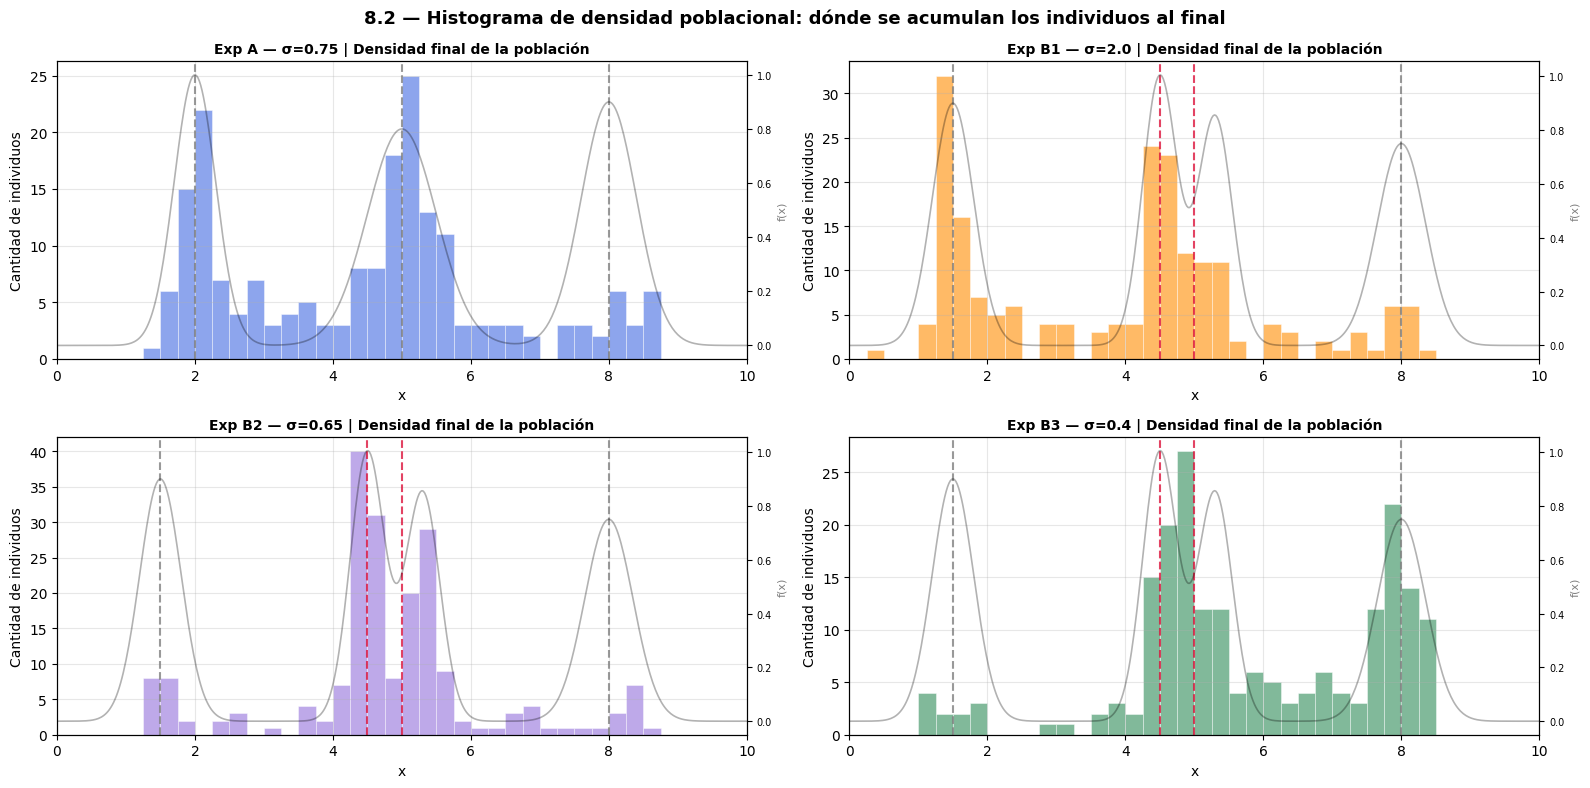

In [9]:
# ==============================================================
# 8.2 — Histograma de densidad poblacional (generación final)
# ==============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

experimentos_hist = [
    {'id': 'A',  'res': res_A,              'fn': objective_function,     'peaks': PEAKS_ORIGINAL,
     'close': [],             'color': 'royalblue',   'sigma': SIGMA_SHARE},
    {'id': 'B1', 'res': resultados_B['B1'], 'fn': objective_function_new, 'peaks': PEAKS_NEW,
     'close': list(CLOSE_PAIR),'color': 'darkorange',  'sigma': SIGMA_B1},
    {'id': 'B2', 'res': resultados_B['B2'], 'fn': objective_function_new, 'peaks': PEAKS_NEW,
     'close': list(CLOSE_PAIR),'color': 'mediumpurple','sigma': SIGMA_B2},
    {'id': 'B3', 'res': resultados_B['B3'], 'fn': objective_function_new, 'peaks': PEAKS_NEW,
     'close': list(CLOSE_PAIR),'color': 'seagreen',    'sigma': SIGMA_B3},
]

x_plot_hist = np.linspace(LOWER_BOUND, UPPER_BOUND, 500)

for ax, exp in zip(axes, experimentos_hist):
    population = exp['res']['population']

    # Histograma de posiciones
    ax.hist(population, bins=40, range=(LOWER_BOUND, UPPER_BOUND),
            color=exp['color'], alpha=0.6, edgecolor='white', linewidth=0.5,
            label='Densidad poblacional')

    # Líneas de picos teóricos
    y_max = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 10
    for px in exp['peaks']:
        es_c = px in exp['close']
        ax.axvline(px, color='crimson' if es_c else 'gray',
                   linestyle='--', linewidth=1.5, alpha=0.8,
                   label=f'Pico teórico x={px}' if px == exp['peaks'][0] else '')

    # Función objetivo escalada para referencia (eje secundario)
    ax2_twin = ax.twinx()
    ax2_twin.plot(x_plot_hist, exp['fn'](x_plot_hist),
                  'k-', linewidth=1.2, alpha=0.3, label='f(x)')
    ax2_twin.set_ylabel("f(x)", fontsize=8, alpha=0.5)
    ax2_twin.tick_params(labelsize=7)

    ax.set_title(f"Exp {exp['id']} — σ={exp['sigma']} | Densidad final de la población",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("Cantidad de individuos")
    ax.set_xlim(LOWER_BOUND, UPPER_BOUND)
    ax.grid(True, alpha=0.3)

plt.suptitle("8.2 — Histograma de densidad poblacional: dónde se acumulan los individuos al final",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión:** La gráfica evidencia una convergencia estable y una preservación efectiva de la calidad de las soluciones a lo largo del proceso evolutivo. Se observa que el valor máximo se alcanza rápidamente y se mantiene constante (meseta), lo que indica que el algoritmo es elitista y no pierde la mejor solución encontrada en cada nicho.

<div style="
    background: linear-gradient(90deg, #1a73e8 0%, #ffffff 100%);
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h2 style="color: white; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ⭐ Planteamiento en el entorno laboral
  </h2>
</div>

- Cada miembro del equipo debe plantear un problema en su
entorno laboral que pueda abordado con la aplicación de
algoritmos genéticos, cada planteamiento debe incluir la definición
de una función objetivo.
- Para cada problema planteado defina ¿Cuál sería la estructura de
los cromosomas considerando los genes, fenotipos, genotipos?

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
  🚀 Aplicación en ámbito laboral: Kamila Viteri Ayala
  </h1>
</div>

# **1. Motivación y Planteamiento del Problema**

La evaluación ex post de proyectos financiados por organismos multilaterales —como el Banco Interamericano de Desarrollo (BID), el Banco Mundial (BM), la Corporación Andina de Fomento (CAF) o el Fondo Internacional de Desarrollo Agrícola (FIDA)— enfrenta un problema estructural que la metodología clásica resuelve de forma incompleta: **la existencia de múltiples escenarios de evaluación igualmente válidos**.

Un informe ex post debe responder preguntas como:

- ¿Cuál es el impacto neto atribuible al proyecto?
- ¿Qué habría ocurrido sin la intervención (contrafactual)?
- ¿Qué combinación de factores explica el resultado observado?
- ¿Es el proyecto económicamente rentable bajo distintos supuestos?

Cada una de estas preguntas admite **múltiples respuestas defensibles** según los supuestos metodológicos adoptados: la tasa de descuento social elegida, el grupo de control construido, la ruta causal privilegiada, o el peso asignado a cada criterio de evaluación. El evaluador, al fijar una única combinación de supuestos, introduce arbitrariedad y oculta la incertidumbre real del análisis.

Este problema es, en términos computacionales, un **problema de optimización multimodal**: la superficie de plausibilidad evaluativa tiene múltiples picos (óptimos locales), cada uno representando un escenario metodológico coherente y bien sustentado. Un algoritmo convencional converge en uno solo; un **Algoritmo Genético con Fitness Sharing** los identifica todos simultáneamente.

---

# **2. Espacio de Búsqueda**

El espacio de búsqueda $\mathcal{X}$ está formado por todas las combinaciones posibles de parámetros metodológicos que un evaluador puede adoptar legítimamente al construir un informe ex post. Se define como:

$$\mathcal{X} = G_1 \times G_2 \times G_3 \times G_4 \times G_5 \times G_6$$

donde cada $G_i$ es el dominio de un parámetro evaluativo (gen). El objetivo es identificar todos los puntos $\mathbf{x} \in \mathcal{X}$ que maximizan simultáneamente la función de plausibilidad $f(\mathbf{x})$, que mide qué tan bien un conjunto de supuestos explica la evidencia observada del proyecto.

---

# **3. Representación Genética**

### 3.1 Cromosoma (Genotipo)

Cada **individuo** representa un escenario de evaluación completo, codificado como un vector de seis genes de valor real:

$$\mathbf{x} = (g_1,\ g_2,\ g_3,\ g_4,\ g_5,\ g_6) \in \mathbb{R}^6$$

Cada gen codifica un parámetro metodológico de la evaluación:

| Gen | Nombre | Dominio | Interpretación |
|-----|--------|---------|----------------|
| $g_1$ | Tasa de descuento social | $[0.03,\ 0.15]$ | Tasa anual usada para calcular el VAN del proyecto |
| $g_2$ | Horizonte de evaluación | $[5,\ 25]$ (años) | Período sobre el cual se proyectan los beneficios |
| $g_3$ | Factor de atribución | $[0.30,\ 1.00]$ | Fracción del resultado observado atribuible al proyecto |
| $g_4$ | Ruta causal dominante | $[0,\ 1]$ | Continuo entre ruta directa (0) e indirecta por spillovers (1) |
| $g_5$ | Peso del criterio de eficiencia DAC | $[0.05,\ 0.40]$ | Ponderación del criterio de eficiencia en la calificación global |
| $g_6$ | Peso del grupo vulnerable en el análisis | $[0.10,\ 0.60]$ | Proporción del análisis de impacto focalizada en subgrupos prioritarios |

> **Nota:** Los genes $g_5$ y $g_6$ forman parte de un vector de ponderaciones que, en la implementación completa, incluiría los seis criterios DAC/OCDE (relevancia, coherencia, eficiencia, efectividad, impacto, sostenibilidad). Para este planteamiento se simplifican a dos dimensiones representativas.

### 3.2 Genotipo

El **genotipo** es la representación interna del individuo: el vector numérico $\mathbf{x}$ que contiene los valores de los seis genes. Este vector es el objeto sobre el que operan los operadores genéticos (selección, cruce, mutación).

Dos genotipos distintos representan dos escenarios de evaluación distintos, incluso si producen resultados similares.

**Ejemplo de genotipo:**

$$\mathbf{x}_1 = (0.08,\ 15,\ 0.72,\ 0.30,\ 0.20,\ 0.35)$$

Esto representa: tasa de descuento del 8%, horizonte de 15 años, 72% del impacto atribuido al proyecto, ruta causal mayormente directa, eficiencia con peso del 20%, y 35% del análisis centrado en grupos vulnerables.

### 3.3 Fenotipo

El **fenotipo** es la expresión observable del genotipo: el conjunto de resultados evaluativos que se derivan de aplicar ese escenario metodológico a los datos del proyecto. Incluye:

- **VAN social estimado:** $\text{VAN}(\mathbf{x}) = \sum_{t=0}^{g_2} \frac{B_t \cdot g_3}{(1 + g_1)^t} - C_0$
- **Calificación global DAC:** $Q(\mathbf{x}) \in [1, 6]$, promedio ponderado de los seis criterios
- **Impacto en subgrupos:** distribución del efecto según $g_6$
- **Ruta causal activa:** narrativa de teoría del cambio según $g_4$

El fenotipo es lo que el evaluador presenta en el informe; el genotipo es el conjunto de supuestos que lo generó.

**Ejemplo de fenotipo correspondiente a $\mathbf{x}_1$:**

> VAN social = USD 4.2M | Calificación global = 4.1/6 (Satisfactorio) | Impacto directo en beneficiarios prioritarios: 35% del efecto total | Ruta causal: capacitación técnica → adopción tecnológica → incremento de ingresos

---

## 4. Función de Fitness

La función de fitness $f(\mathbf{x})$ mide la **plausibilidad metodológica** de un escenario de evaluación: qué tan bien el conjunto de supuestos codificado en $\mathbf{x}$ es consistente con la evidencia empírica disponible del proyecto (datos de monitoreo, encuestas de beneficiarios, registros administrativos, auditorías).

Se define como una función compuesta:

$$f(\mathbf{x}) = w_{\text{van}} \cdot \phi_{\text{van}}(\mathbf{x}) + w_{\text{dac}} \cdot \phi_{\text{dac}}(\mathbf{x}) + w_{\text{imp}} \cdot \phi_{\text{imp}}(\mathbf{x}) + w_{\text{coh}} \cdot \phi_{\text{coh}}(\mathbf{x})$$

donde:

| Componente | Descripción | Peso sugerido |
|------------|-------------|---------------|
| $\phi_{\text{van}}(\mathbf{x})$ | Consistencia del VAN con los rangos de referencia sectorial del organismo | $w_{\text{van}} = 0.30$ |
| $\phi_{\text{dac}}(\mathbf{x})$ | Coherencia de la calificación DAC con la evidencia documental | $w_{\text{dac}} = 0.35$ |
| $\phi_{\text{imp}}(\mathbf{x})$ | Compatibilidad del impacto estimado con estudios de línea de base | $w_{\text{imp}} = 0.25$ |
| $\phi_{\text{coh}}(\mathbf{x})$ | Coherencia interna entre los seis genes (sin contradicciones metodológicas) | $w_{\text{coh}} = 0.10$ |

Cada componente $\phi_i(\mathbf{x}) \in [0, 1]$, por lo que $f(\mathbf{x}) \in [0, 1]$.

### Carácter multimodal de la función de fitness

La superficie $f(\mathbf{x})$ es **multimodal** porque existen varias combinaciones de supuestos que maximizan localmente la plausibilidad. Algunos ejemplos de configuraciones que forman picos distintos:

- **Pico A (escenario conservador):** tasa alta (12%), horizonte corto (8 años), atribución baja (40%) → VAN moderado, calificación defensible ante auditoría.
- **Pico B (escenario desarrollista):** tasa baja (5%), horizonte largo (20 años), atribución alta (85%) → VAN elevado, justifica continuidad del programa.
- **Pico C (escenario de equidad):** peso alto en grupos vulnerables (55%), ruta causal indirecta → impacto redistributivo prioritario, alineado con mandato social del organismo.
- **Pico D (escenario técnico-eficientista):** peso alto en eficiencia DAC (35%), atribución media (65%), ruta directa → calificación técnica alta, orientado a lecciones operativas.

Un AG convencional convergería en **uno de estos escenarios**. El AG con Fitness Sharing los mantiene **todos vivos** en la población final.

---

## 5. Ventajas frente al Enfoque Convencional

| Aspecto | Enfoque convencional | AG con Fitness Sharing |
|---|---|---|
| Contrafactual | Único, fijado por el evaluador | Múltiples, explorados sistemáticamente |
| Sensibilidad | Análisis puntual de 2-3 escenarios ad hoc | Mapa completo de la superficie de plausibilidad |
| Transparencia | Supuestos implícitos | Supuestos explícitos como genes del cromosoma |
| Riesgo de sesgo | Alto (el evaluador elige los supuestos que favorecen su narrativa) | Bajo (el algoritmo explora el espacio sin sesgo) |
| Requerimiento de datos | Igual | Igual |
| Aceptabilidad metodológica | Alta (convención) | Emergente (requiere justificación ante el comité) |

---

## Conclusión

El Algoritmo Genético con Fitness Sharing proporciona una **arquitectura formal** para responder a la pregunta más difícil de la evaluación ex post: *¿cuántas respuestas igualmente válidas existen?* Al codificar los supuestos metodológicos como genes, los escenarios evaluativos como individuos, y la plausibilidad empírica como fitness, el algoritmo convierte la incertidumbre metodológica —que habitualmente se oculta en los informes— en información estructurada y transparente.

Los picos identificados no son errores del algoritmo: son los **equilibrios del espacio evaluativo**, cada uno representando una posición metodológica coherente que un evaluador razonable podría defender. Presentarlos explícitamente en el informe ex post eleva la calidad técnica del análisis y responde directamente a los estándares de rigor exigidos por las unidades de evaluación independiente de los organismos multilaterales.

<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
  🚀 Aplicación en ámbito laboral: Juan Pablo Sánchez
  </h1>
</div>

**1. Definición del Problema: Despliegue de Nodos ISP**

En el sector de las telecomunicaciones, la ubicación estratégica de nodos de distribución de Internet (WISP) es crítica para rentabilizar la inversión. El desafío consiste en maximizar la cobertura en una avenida de 10 km donde la demanda de los clientes (densidad poblacional) es multimodal (existen múltiples zonas de alta demanda separadas por terrenos baldíos o parques).

•	**Objetivo:** Identificar las 4 ubicaciones óptimas que capturen la mayor densidad de clientes.

•	**Restricción de Negocio:** Evitar el solapamiento de señales e interferencia de radiofrecuencia (RF), garantizando una separación mínima de 1 km entre nodos.

**2. Mapeo al Modelo Evolutivo**

Para resolver este problema mediante Algoritmos Genéticos (AG), definimos la siguiente estructura de datos:

•	**El Gen:** Representa una coordenada escalar única x [0, 10], que indica el punto kilométrico de instalación.

•	**El Cromosoma** (Individuo): Un vector de 4 genes [g1, g2, g3, g4], que representa un plan completo de despliegue de red.

•	**El Genotipo:** Codificación de valor real para permitir micro-ajustes en la ubicación mediante mutación gaussiana.

•	**El Fenotipo:** La configuración física de los nodos en la avenida y su correspondiente área de cobertura resultante.

**3. Función de Aptitud (Fitness) y Mecanismo de Nichos**

La evaluación de cada solución no solo depende de la "riqueza" del punto (cuántos clientes hay), sino de la eficiencia de la distribución:

  1.	Aptitud Bruta: Calculada como la suma de la densidad de clientes en las 4 coordenadas propuestas. Se busca maximizar esta suma.
  2.	Mecanismo de Fitness Sharing: Se aplica para satisfacer la restricción técnica de no interferencia.

    o	Si dos nodos (gi, gj) están a una distancia menor a sigma = 1.0 km, se penaliza su aptitud.

    o	Esto obliga a los "genes" dentro del cromosoma a repelerse entre sí, buscando diferentes picos de demanda en lugar de amontonarse en el punto de mayor tráfico.

**4. Resultados Esperados y Valor Agregado**

Al implementar esta solución, el área de Telecomunicaciones de TI logra:

•	Cobertura Total: Los nodos "colonizan" los 4 clústeres de mayor demanda de forma automática.

•	Eficiencia de Espectro: Se minimiza la interferencia de RF al mantener los nodos en nichos separados.

•	Escalabilidad: El modelo puede adaptarse dinámicamente si la densidad de clientes cambia (nuevas edificaciones), permitiendo una re-optimización del despliegue con un costo computacional mínimo.

**Gráfica de referencia**

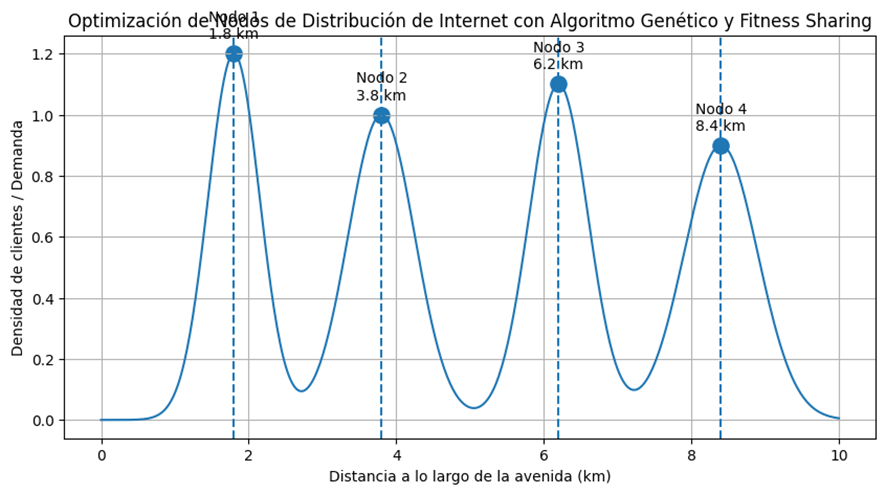


<div style="
    background: #ffffff;
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h1 style="color: blue; margin: 0; font-size: 20px; font-weight: bold; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
  🚀 Aplicación en ámbito laboral: Ximena Rodríguez Vélez
  </h1>
</div>

# 1. Motivación y Planteamiento del Problema

**Problema:** En plataformas bancarias de Pago de Tarjetas y Planillas, la ejecución de regresiones completas tras cada actualización es inviable por los tiempos de entrega. El QA Senior debe seleccionar un subconjunto de pruebas que mitigue el mayor riesgo financiero posible en una ventana de tiempo limitada.

**Motivación:** No existe un único "Plan de Pruebas" perfecto. Dependiendo del tipo de cambio en el código, el éxito puede verse como una regresión que asegura el movimiento de dinero (Nicho Financiero) o una que asegura que el cliente vea sus saldos correctamente (Nicho de Interfaz). Un Algoritmo Genético Multimodal con Fitness Sharing permite identificar estas distintas estrategias óptimas simultáneamente, evitando que el equipo se enfoque en un solo tipo de prueba y deje "puntos ciegos" en otros riesgos.

# 2. Espacio de Búsqueda
El espacio de búsqueda es continuo y está acotado por los límites de configuración de la estrategia de QA. Se define como el conjunto de todas las combinaciones posibles de niveles de intensidad (0 a 1) para las dimensiones de:

- Priorización de funcionalidades críticas.
- Esfuerzo de automatización.
- Cobertura de defectos históricos.
- Verificación de consistencia visual en pantalla.

# 3. Representación Genética

**3.1 Cromosoma (Genotipo)**
Se utiliza una representación de punto flotante. Cada cromosoma es un vector que codifica la configuración de la estrategia:

1.   Gen 1 - Foco Financiero ($G_f$): Peso asignado a transacciones monetarias puras.
2.   Gen 2 - Nivel de Automatización ($G_a$): Ratio de pruebas automáticas frente a manuales.
3. Gen 3 - Riesgo Histórico ($G_h$): Intensidad de pruebas en módulos con alta recurrencia de errores pasados.
4. Gen 4 - Integridad Visual ($G_v$): Importancia dada a la experiencia de usuario y pantallas.

**3.2 Genotipo y Fenotipo**
- **Genotipo:** Es la estructura interna de datos que el algoritmo procesa (ej: [0.92, 0.75, 0.20, 0.10]).

- **Fenotipo:** Es la Estrategia de Regresión resultante. Se traduce en un plan de ejecución real: *"Ejecutar 92% de pruebas financieras, priorizando scripts automáticos y enfocando solo el 20% del tiempo en módulos con fallos previos*".

# 4. Función de Fitness (Aptitud)

La meta es maximizar la Cobertura de Riesgo ($CR$) optimizando el Tiempo ($T$).

$$f(x) = \frac{(ImpactoFinanciero \cdot W_1) + (ProbabilidadFallo \cdot W_2)}{T \cdot CostoRecursos}$$

- Premios: Se asigna mayor aptitud a cromosomas que cubren HU de alto valor (como Pagos de Planillas).

- Penalizaciones: Si la duración estimada de la regresión ($T$) supera la ventana de mantenimiento bancario, el individuo es penalizado drásticamente, disminuyendo su probabilidad de reproducción.

# Conclusiones
- Gracias a la técnica de niching, el algoritmo no converge a una única solución. Identifica nichos separados como el "Critical Path" (flujo de dinero) y el de "Estabilidad UI" (experiencia cliente). Esto garantiza que el QA Senior tenga opciones de prueba diversificadas.
- La aplicación de AG permite automatizar la toma de decisiones compleja. En lugar de seleccionar casos de prueba por intuición, se utiliza un motor de optimización que garantiza que, independientemente del tiempo disponible, los "picos" de mayor riesgo del banco siempre estén cubiertos.
- Sensibilidad del Parámetro SIGMA_SHARE: En la experimentación técnica se demostró que un $\sigma_{share}$ adecuado es vital. Si es muy grande, el algoritmo podría fusionar la estrategia de "Pago de Tarjetas" con la de "Pago de Planillas", ignorando sus diferencias sutiles pero críticas.